# Cross-Market SNN Portfolio Optimization — PyTorch + snnTorch

This notebook converts the MATLAB portfolio-optimization workflow into a **PyTorch/snnTorch** implementation and, importantly, replaces the original full-period/random-return evaluation with a **chronological out-of-sample backtest**.

**Train:** 2018-07-01 → 2023-06-30  
**Test:** 2023-07-01 → 2025-06-30

Core methodology:
1. Download Nifty 500 + S&P 500 constituent price data.
2. Clean prices and compute daily log returns.
3. Perform all asset selection/clustering using **training data only**.
4. Build return, volatility and correlation features from training data.
5. Train an SNN portfolio-weight optimizer with population coding, LIF neurons, adaptive thresholds, lateral inhibition and a Sharpe-based objective.
6. Train an ANN baseline with Xavier initialization, ReLU and Adam.
7. Freeze both models.
8. Evaluate their fixed portfolio weights on the unseen 2023-07-01 → 2025-06-30 daily returns.
9. Report cumulative return, CAGR, rolling Sharpe, volatility, maximum drawdown and turnover.

> **Important:** This is a faithful redesign of the repository's optimization idea, not a line-for-line MATLAB translation. The original repository computes statistics over the full dataset and simulates 252 random historical days; this notebook deliberately removes that leakage and performs a real chronological test.

In [1]:
# Cell 1 — Install dependencies
# Run once in a fresh notebook environment.

%pip install -q yfinance pandas numpy scipy scikit-learn matplotlib seaborn torch snntorch

In [2]:
# Cell 2 — Imports, reproducibility and configuration

import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

import snntorch as snn
from snntorch import surrogate

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

TRAIN_START = "2018-07-01"
TRAIN_END   = "2023-06-30"

TEST_START  = "2023-07-01"
TEST_END    = "2025-06-30"

# yfinance end dates are exclusive, so use the next day.
DOWNLOAD_START = TRAIN_START
DOWNLOAD_END   = "2025-07-01"

MIN_COMPLETENESS = 0.90

# Portfolio constraints from the MATLAB/paper setup.
K_MIN = 30
K_MAX = 50

TRANSACTION_COST = 0.0025

# SNN settings. 120 is the paper-style population size; 16 is a
# practical default for notebook experimentation. Change to 120
# after validating the pipeline if you want a closer reproduction.
POP_SIZE = 120
SNN_STEPS = 10
SNN_LR = 0.20
SNN_EPOCHS = 250

ANN_HIDDEN = 16
ANN_EPOCHS = 150
ANN_LR = 0.02

K_MIN = 30
K_MAX = 50

TRANSACTION_COST = 0.0025

RISK_AVERSION = 0.85

CARDINALITY_PENALTY = 0.01
DIVERSITY_PENALTY = 0.01

# Set True only if you want to reduce the universe before optimization.
USE_CLUSTERING = True

# If None, candidate k values are evaluated by silhouette score.
# Keep this modest for a first run. You can later include larger k.
CLUSTER_CANDIDATES = [10, 20, 30, 40, 50]

print("Train:", TRAIN_START, "to", TRAIN_END)
print("Test :", TEST_START, "to", TEST_END)

Device: cuda
Train: 2018-07-01 to 2023-06-30
Test : 2023-07-01 to 2025-06-30


## Cell 3 — Build the historical S&P 500 + Nifty 500 universe

This version **does not use the repository `tickers_list.txt`**.

There are two supported universe modes:

1. **`point_in_time` (recommended):** use the stocks that actually belonged to each index during the relevant historical period. This avoids survivorship bias.
2. **`continuous_survivors`:** keep only stocks that appear in every historical constituent snapshot from 2018-07 through 2025-06. This matches the literal “present for the whole duration” requirement, but it introduces survivorship bias.

For S&P 500, the notebook reads monthly historical constituent snapshots.

For Nifty 500, place a historical constituent ledger exported from a historical Nifty constituent source (for example, Niftyhistory.in) in the notebook directory. The ledger should contain at least `effective_date`, `action`, and `symbol` columns, where action is `ADD` or `REMOVE`.

The model itself still trains only on 2018-07-01 → 2023-06-30 and tests only on 2023-07-01 → 2025-06-30.


In [3]:
# Cell 3 — Historical constituent loaders (no repository ticker list)

import io
import requests
import pandas as pd
import numpy as np
from pathlib import Path
import ast
import re

TRAIN_START = pd.Timestamp("2018-07-01")
TRAIN_END   = pd.Timestamp("2023-06-30")
TEST_START  = pd.Timestamp("2023-07-01")
TEST_END    = pd.Timestamp("2025-06-30")

# Recommended research setting:
# - point_in_time: use the historical constituents available at each date
# - continuous_survivors: only companies present in every snapshot
UNIVERSE_MODE = "point_in_time"

# Historical S&P 500 constituent snapshots
SP500_BASE_URL = (
    "https://raw.githubusercontent.com/"
    "pierrebrunelle/sp500-historical-constituents/main/data"
)

# Your downloaded Nifty 500 historical constituent file
NIFTY_LEDGER_PATH = Path("nifty500_constituent_events.csv")


# ---------------------------------------------------------
# 1. Ticker normalization
# ---------------------------------------------------------

def normalize_us_ticker(ticker):
    """
    Normalize S&P 500 ticker for Yahoo Finance.
    Example:
        BRK.B -> BRK-B
        BF.B  -> BF-B
    """
    ticker = str(ticker).strip().upper()
    return ticker.replace(".", "-").replace("/", "-")


def normalize_indian_ticker(ticker):
    """
    Normalize historical Nifty ticker symbols.
    """
    ticker = str(ticker).strip().upper()

    # Remove accidental whitespace
    ticker = ticker.replace(" ", "")

    # Remove surrounding quotes if present
    ticker = ticker.strip("'\"")

    return ticker


# ---------------------------------------------------------
# 2. Load historical S&P 500 snapshots
# ---------------------------------------------------------

def load_sp500_snapshots(start=TRAIN_START, end=TEST_END):

    months = pd.period_range(
        start=start,
        end=end,
        freq="M"
    )

    snapshots = {}

    for period in months:

        ym = period.strftime("%Y%m")

        url = f"{SP500_BASE_URL}/spy{ym}"

        try:
            response = requests.get(
                url,
                timeout=30
            )

            response.raise_for_status()

            tickers = []

            for line in response.text.splitlines():

                parts = line.split("\t")

                if len(parts) > 0:

                    ticker = parts[0].strip()

                    if ticker:
                        tickers.append(
                            normalize_us_ticker(ticker)
                        )

            snapshot_date = (
                period.to_timestamp(how="end")
                .normalize()
            )

            snapshots[snapshot_date] = set(tickers)

        except Exception as e:

            print(
                f"Warning: could not load S&P snapshot "
                f"{ym}: {e}"
            )

    if not snapshots:

        raise ValueError(
            "No S&P 500 historical snapshots were loaded."
        )

    return snapshots


# ---------------------------------------------------------
# 3. Parse the symbols column from your Nifty CSV
# ---------------------------------------------------------

def parse_symbol_list(value):

    """
    Converts the symbols column into a Python set.

    Handles formats such as:

        ['RELIANCE', 'TCS', 'INFY']

    or

        "['RELIANCE', 'TCS', 'INFY']"

    or comma-separated strings.
    """

    if pd.isna(value):

        return set()

    value = str(value).strip()

    # Try Python-list representation first
    try:

        parsed = ast.literal_eval(value)

        if isinstance(parsed, (list, tuple, set)):

            return {
                normalize_indian_ticker(x)
                for x in parsed
                if str(x).strip()
            }

    except Exception:
        pass

    # Fallback: remove brackets and split by comma
    value = value.strip("[]")

    symbols = re.split(
        r",\s*",
        value
    )

    return {
        normalize_indian_ticker(
            x.strip("'\" ")
        )
        for x in symbols
        if x.strip("'\" ")
    }


# ---------------------------------------------------------
# 4. Load historical Nifty 500 snapshots
# ---------------------------------------------------------

def load_nifty_snapshots(path=NIFTY_LEDGER_PATH):

    if not path.exists():

        raise FileNotFoundError(
            f"{path} not found.\n"
            f"Make sure the downloaded Nifty 500 CSV "
            f"is in the same directory as this notebook."
        )

    df = pd.read_csv(path)

    # Normalize column names
    df.columns = [
        str(c).strip().lower()
        for c in df.columns
    ]

    print("Nifty CSV columns:")
    print(df.columns.tolist())

    # Your file contains:
    #
    # effective_date
    # index_type
    # inclusions
    # exclusions
    # symbols

    required = {
        "effective_date",
        "symbols"
    }

    missing = required - set(df.columns)

    if missing:

        raise ValueError(
            f"Nifty CSV missing required columns: "
            f"{sorted(missing)}\n"
            f"Available columns: {df.columns.tolist()}"
        )

    # Convert dates
    df["effective_date"] = pd.to_datetime(
        df["effective_date"],
        errors="coerce"
    )

    # Remove invalid dates
    df = df.dropna(
        subset=["effective_date"]
    )

    # Keep only Nifty 500 rows if index_type exists
    if "index_type" in df.columns:

        df["index_type"] = (
            df["index_type"]
            .astype(str)
            .str.upper()
            .str.strip()
        )

        nifty_mask = (
            df["index_type"]
            .str.contains(
                "NIFTY500|NIFTY 500",
                regex=True,
                na=False
            )
        )

        if nifty_mask.any():

            df = df[nifty_mask].copy()

    # Keep requested historical period
    df = df[
        (df["effective_date"] >= TRAIN_START)
        & (df["effective_date"] <= TEST_END)
    ].copy()

    # Convert symbols column into sets
    df["constituent_set"] = (
        df["symbols"]
        .apply(parse_symbol_list)
    )

    # Sort chronologically
    df = df.sort_values(
        "effective_date"
    ).reset_index(drop=True)

    snapshots = {}

    for _, row in df.iterrows():

        date = pd.Timestamp(
            row["effective_date"]
        ).normalize()

        symbols = row["constituent_set"]

        if len(symbols) > 0:

            snapshots[date] = symbols

    if not snapshots:

        raise ValueError(
            "No valid Nifty 500 constituent snapshots "
            "were found in the CSV."
        )

    return snapshots


# ---------------------------------------------------------
# 5. Build the requested universe
# ---------------------------------------------------------

def get_universe_from_snapshots(
    snapshots,
    mode="point_in_time"
):

    sets = list(snapshots.values())

    if not sets:

        raise ValueError(
            "No constituent snapshots available."
        )

    if mode == "continuous_survivors":

        # Companies appearing in EVERY snapshot
        return set.intersection(*sets)

    elif mode == "point_in_time":

        # Every company that was a constituent
        # at least once during the historical period.
        return set.union(*sets)

    else:

        raise ValueError(
            "mode must be either "
            "'point_in_time' or "
            "'continuous_survivors'"
        )


# ---------------------------------------------------------
# 6. Load both markets
# ---------------------------------------------------------

print("\nLoading historical S&P 500 constituents...")

sp500_snapshots = load_sp500_snapshots(
    TRAIN_START,
    TEST_END
)

print(
    f"S&P snapshots loaded: "
    f"{len(sp500_snapshots)}"
)


print("\nLoading historical Nifty 500 constituents...")

nifty_snapshots = load_nifty_snapshots(
    NIFTY_LEDGER_PATH
)

print(
    f"Nifty snapshots loaded: "
    f"{len(nifty_snapshots)}"
)


# ---------------------------------------------------------
# 7. Construct historical universes
# ---------------------------------------------------------

sp500_universe = get_universe_from_snapshots(
    sp500_snapshots,
    UNIVERSE_MODE
)

nifty_universe = get_universe_from_snapshots(
    nifty_snapshots,
    UNIVERSE_MODE
)


# ---------------------------------------------------------
# 8. Cross-market universe
# ---------------------------------------------------------

cross_market_universe = (
    sp500_universe |
    nifty_universe
)


# ---------------------------------------------------------
# 9. Summary
# ---------------------------------------------------------

print("\n" + "=" * 60)
print("HISTORICAL CONSTITUENT SUMMARY")
print("=" * 60)

print(
    f"S&P 500 historical universe : "
    f"{len(sp500_universe)}"
)

print(
    f"Nifty 500 historical universe: "
    f"{len(nifty_universe)}"
)

print(
    f"Cross-market universe        : "
    f"{len(cross_market_universe)}"
)

print(
    f"Universe mode                : "
    f"{UNIVERSE_MODE}"
)

print(
    f"Historical period            : "
    f"{TRAIN_START.date()} → {TEST_END.date()}"
)

print("=" * 60)


# ---------------------------------------------------------
# 10. Survivorship-bias warning
# ---------------------------------------------------------

if UNIVERSE_MODE == "continuous_survivors":

    print(
        "\nWARNING:"
        "\ncontinuous_survivors selects only companies "
        "present throughout the entire period."
        "\nThis introduces survivorship bias."
        "\n"
        "\nUse UNIVERSE_MODE = 'point_in_time' "
        "for the primary research experiment."
    )


Loading historical S&P 500 constituents...
S&P snapshots loaded: 84

Loading historical Nifty 500 constituents...
Nifty CSV columns:
['effective_date', 'index_type', 'inclusions', 'exclusions', 'symbols']
Nifty snapshots loaded: 26

HISTORICAL CONSTITUENT SUMMARY
S&P 500 historical universe : 622
Nifty 500 historical universe: 615
Cross-market universe        : 1233
Universe mode                : point_in_time
Historical period            : 2018-07-01 → 2025-06-30


## Cell 4 — Download prices

We download the entire period once, but **the test period will not be used to calculate any training statistics or to choose assets**.

`auto_adjust=True` adjusts historical prices for corporate actions. If you need exact replication of the original MATLAB price series, use the same price field as the original data file instead.

In [4]:
# Cell 4 — Download daily prices for historical universe

import yfinance as yf
import pandas as pd
import numpy as np

# ---------------------------------------------------------
# 1. Market-specific Yahoo ticker mapping
# ---------------------------------------------------------

sp500_yahoo = {
    ticker: normalize_us_ticker(ticker)
    for ticker in sp500_universe
}

nifty_yahoo = {
    ticker: f"{normalize_indian_ticker(ticker)}.NS"
    for ticker in nifty_universe
}

YAHOO_TICKERS = {
    **sp500_yahoo,
    **nifty_yahoo
}

print("S&P 500 historical tickers :", len(sp500_universe))
print("Nifty 500 historical tickers:", len(nifty_universe))
print(
    "Duplicate raw symbols       :",
    len(set(sp500_universe) & set(nifty_universe))
)


# ---------------------------------------------------------
# 2. Download prices
# ---------------------------------------------------------

print("\nDownloading historical prices...")

raw = yf.download(
    list(YAHOO_TICKERS.values()),
    start=str(TRAIN_START.date()),
    end=str((TEST_END + pd.Timedelta(days=1)).date()),
    auto_adjust=True,
    progress=False,
    threads=True
)


# ---------------------------------------------------------
# 3. Extract Close prices
# ---------------------------------------------------------

if isinstance(raw.columns, pd.MultiIndex):

    if "Close" in raw.columns.get_level_values(0):
        prices = raw["Close"].copy()
    else:
        raise ValueError(
            "Could not find Close prices in yfinance output."
        )

else:

    if "Close" in raw.columns:
        prices = raw[["Close"]].copy()
    else:
        raise ValueError(
            "Could not find Close prices in yfinance output."
        )


# ---------------------------------------------------------
# 4. Rename Yahoo tickers → original symbols
# ---------------------------------------------------------

reverse_map = {
    yahoo_ticker: original_ticker
    for original_ticker, yahoo_ticker
    in YAHOO_TICKERS.items()
}

prices = prices.rename(columns=reverse_map)

prices = prices.sort_index()


# ---------------------------------------------------------
# 5. IMPORTANT:
#    Detect actual price availability
# ---------------------------------------------------------

# A ticker is considered successfully downloaded only if
# it contains at least SOME real price observations.

available_columns = []

for ticker in prices.columns:

    if prices[ticker].notna().sum() > 0:
        available_columns.append(ticker)


downloaded = available_columns

failed = sorted(
    set(YAHOO_TICKERS.keys()) -
    set(downloaded)
)

prices = prices[downloaded]


# ---------------------------------------------------------
# 6. Print download summary
# ---------------------------------------------------------

print("\n" + "=" * 60)
print("PRICE DOWNLOAD SUMMARY")
print("=" * 60)

print(
    "Requested:",
    len(YAHOO_TICKERS)
)

print(
    "Downloaded with actual data:",
    len(downloaded)
)

print(
    "Failed / no price data:",
    len(failed)
)

print(
    "Date range:",
    prices.index.min().date(),
    "→",
    prices.index.max().date()
)

print("=" * 60)


if failed:

    print("\nFirst 50 failed/missing tickers:")

    for ticker in failed[:50]:
        print(" ", ticker)

S&P 500 historical tickers : 622
Nifty 500 historical tickers: 615
Duplicate raw symbols       : 4



ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: PUNJTRACT.NS"}}}
ERROR:yfinance:
192 Failed downloads:
ERROR:yfinance:['PUNJTRACT.NS', 'HOGANAS.NS', 'MONSANTO.NS', '852IIFL29.NS', 'SRCL', 'THIRU.NS', 'SEE', 'DSQSOFTW.NS', 'KSU', 'TATAMOTORS.NS', 'HINDUSTAN.NS', 'MOTHERSUMI.NS', 'AKZOINDIA.NS', 'GARWARE.NS', 'SANGHI.NS', 'JNPR', 'SIVB', 'MERCK.NS', 'CA', 'WIMCO.NS', 'JUBLINGRY.NS', 'CERN', 'PHOENIX.NS', 'SCHENECT.NS', 'MXIM', 'IBVENTURES.NS', 'VIAB', 'INFIBEAM.NS', 'ESSAR.NS', 'COX&KINGS.NS', 'TAMIL.NS', 'FAGBEARI.NS', 'LAKSHMI.NS', 'ANSS', 'GPS', 'ZANDU.NS', 'AMBALAL.NS', 'JWN', 'ATVI', 'WINDMACH.NS', 'REIAGRO.NS', 'PSIDATA.NS', 'TODAYS.NS', 'ELECTREX.NS', 'BAJAJ.NS', 'PATSPIN.NS', 'XEC', 'NATIONAL.NS', 'BLOWPLAST.NS', 'SPICEJET.NS', 'WCG', 'BK', 'VAR', 'FBHS', 'TSS', 'AGN', 'EXCEL.NS', 'DFS', 'KINETIC.NS', 'BHUSHANSTL.NS', 'ABMD', 'CELG', 'HOLX', 'GSKCONS.NS', 'PBCT', 'GKNDRIVE.NS', 'ETFC', 'WBA', 'ME


PRICE DOWNLOAD SUMMARY
Requested: 1233
Downloaded with actual data: 1041
Failed / no price data: 192
Date range: 2018-07-02 → 2025-06-30

First 50 failed/missing tickers:
  852IIFL29
  8KMILES
  ABANOFFSH
  ABMD
  ADS
  AGCNETWO
  AGN
  AKZOINDIA
  ALTOS
  ALXN
  AMBALAL
  ANSS
  APC
  APPAPER
  APPLE
  ARNC
  ASTRAZENCA
  ATVI
  AVB
  AVERY
  BAJAJ
  BHUSHANSTL
  BI
  BK
  BLOWPLAST
  BRFL
  BURGER
  CA
  CABLE
  CAPLIN
  CELG
  CENTURYTEX
  CERN
  CHEMINOR
  CHETTINAD
  CMA
  CMC
  COX&KINGS
  CTLT
  CTRA
  CTXS
  CXO
  DAY
  DCLPOLYE
  DFS
  DHFL
  DISCA
  DISCK
  DISH
  DRE


## Cell 5 — Training-only asset filtering

This is an important leakage-control step.

Asset completeness is measured **only on the training period**. We do not use the test period to decide which assets are eligible.

Missing training prices are forward/backward filled after the completeness filter. The same selected asset universe is then carried into the test period.

In [5]:
# Cell 5 — Training-period data quality and asset eligibility

# ---------------------------------------------------------
# 1. Split prices chronologically
# ---------------------------------------------------------

train_prices = prices.loc[
    TRAIN_START:TRAIN_END
].copy()

test_prices = prices.loc[
    TEST_START:TEST_END
].copy()


# ---------------------------------------------------------
# 2. Calculate training-period data completeness
# ---------------------------------------------------------

train_observations = train_prices.notna().sum()
train_total_days = len(train_prices)

train_completeness = (
    train_observations / train_total_days
)


# ---------------------------------------------------------
# 3. Calculate test-period data completeness
# ---------------------------------------------------------

test_observations = test_prices.notna().sum()
test_total_days = len(test_prices)

test_completeness = (
    test_observations / test_total_days
)


# ---------------------------------------------------------
# 4. Create asset-quality table
# ---------------------------------------------------------

asset_quality = pd.DataFrame({
    "train_observations": train_observations,
    "train_completeness": train_completeness,
    "test_observations": test_observations,
    "test_completeness": test_completeness
})

asset_quality.index.name = "ticker"


# ---------------------------------------------------------
# 5. Training eligibility
# ---------------------------------------------------------
#
# Important:
# Asset selection is based ONLY on training data.
#
# We require at least 90% training-period price coverage.

MIN_TRAIN_COMPLETENESS = 0.90

train_eligible = asset_quality[
    asset_quality["train_completeness"]
    >= MIN_TRAIN_COMPLETENESS
].index.tolist()


print("\n" + "=" * 60)
print("TRAINING DATA QUALITY")
print("=" * 60)

print(
    "Total downloaded assets:",
    len(prices.columns)
)

print(
    "Training-eligible assets:",
    len(train_eligible)
)

print(
    "Training period:",
    TRAIN_START.date(),
    "→",
    TRAIN_END.date()
)

print(
    "Minimum training completeness:",
    f"{MIN_TRAIN_COMPLETENESS:.0%}"
)

print("=" * 60)


# ---------------------------------------------------------
# 6. Keep training-eligible assets
# ---------------------------------------------------------

train_prices = train_prices[
    train_eligible
].copy()

test_prices = test_prices[
    train_eligible
].copy()


# ---------------------------------------------------------
# 7. Fill missing observations
# ---------------------------------------------------------
#
# IMPORTANT:
# We only fill short internal/edge gaps after deciding
# eligibility from the original training completeness.

train_prices = (
    train_prices
    .ffill()
    .bfill()
)

test_prices = (
    test_prices
    .ffill()
    .bfill()
)


# ---------------------------------------------------------
# 8. Remove assets that still have no usable data
# ---------------------------------------------------------

valid_after_fill = [
    ticker
    for ticker in train_prices.columns
    if train_prices[ticker].notna().sum() > 0
    and test_prices[ticker].notna().sum() > 0
]

train_prices = train_prices[
    valid_after_fill
]

test_prices = test_prices[
    valid_after_fill
]


# ---------------------------------------------------------
# 9. Final summary
# ---------------------------------------------------------

print("\nFINAL PRICE MATRICES")
print("-" * 60)

print(
    "Training matrix:",
    train_prices.shape
)

print(
    "Testing matrix :",
    test_prices.shape
)

print(
    "Final assets   :",
    len(valid_after_fill)
)

print(
    "Training dates :",
    train_prices.index.min().date(),
    "→",
    train_prices.index.max().date()
)

print(
    "Testing dates  :",
    test_prices.index.min().date(),
    "→",
    test_prices.index.max().date()
)


TRAINING DATA QUALITY
Total downloaded assets: 1041
Training-eligible assets: 960
Training period: 2018-07-01 → 2023-06-30
Minimum training completeness: 90%

FINAL PRICE MATRICES
------------------------------------------------------------
Training matrix: (1297, 960)
Testing matrix : (518, 960)
Final assets   : 960
Training dates : 2018-07-02 → 2023-06-30
Testing dates  : 2023-07-03 → 2025-06-30


In [6]:
# Cell 6 — Calculate daily returns and training-only statistics

# ---------------------------------------------------------
# 1. Calculate daily log returns
# ---------------------------------------------------------

train_returns = np.log(
    train_prices / train_prices.shift(1)
).dropna(how="all")

test_returns = np.log(
    test_prices / test_prices.shift(1)
).dropna(how="all")


# ---------------------------------------------------------
# 2. Keep the same asset universe
# ---------------------------------------------------------

common_assets = (
    train_returns.columns
    .intersection(test_returns.columns)
)

train_returns = train_returns[
    common_assets
].copy()

test_returns = test_returns[
    common_assets
].copy()


# ---------------------------------------------------------
# 3. Handle any remaining missing returns
# ---------------------------------------------------------

# At this point, assets have already passed the
# training completeness filter.

train_returns = train_returns.replace(
    [np.inf, -np.inf],
    np.nan
)

test_returns = test_returns.replace(
    [np.inf, -np.inf],
    np.nan
)


# ---------------------------------------------------------
# 4. Training-only statistics
# ---------------------------------------------------------
#
# IMPORTANT:
# These statistics are calculated ONLY from training data.
# Test data is not used here.

mean_return = (
    train_returns
    .mean(axis=0)
)

volatility = (
    train_returns
    .std(axis=0)
)

cov_matrix = (
    train_returns
    .cov()
)

correlation_matrix = (
    train_returns
    .corr()
)


# ---------------------------------------------------------
# 5. Annualized statistics
# ---------------------------------------------------------

TRADING_DAYS = 252

annual_mean_return = (
    mean_return * TRADING_DAYS
)

annual_volatility = (
    volatility * np.sqrt(TRADING_DAYS)
)


# ---------------------------------------------------------
# 6. Training Sharpe ratio
# ---------------------------------------------------------

training_sharpe = (
    annual_mean_return /
    annual_volatility.replace(0, np.nan)
)


# ---------------------------------------------------------
# 7. Summary
# ---------------------------------------------------------

print("\n" + "=" * 60)
print("RETURN & STATISTICS SUMMARY")
print("=" * 60)

print(
    "Training return matrix:",
    train_returns.shape
)

print(
    "Testing return matrix :",
    test_returns.shape
)

print(
    "Number of assets      :",
    len(common_assets)
)

print(
    "Covariance matrix     :",
    cov_matrix.shape
)

print(
    "Correlation matrix    :",
    correlation_matrix.shape
)

print("=" * 60)


# ---------------------------------------------------------
# 8. Display top training Sharpe assets
# ---------------------------------------------------------

top_sharpe = (
    training_sharpe
    .sort_values(ascending=False)
    .head(20)
)

print("\nTop 20 assets by TRAINING Sharpe:")
print(top_sharpe)


RETURN & STATISTICS SUMMARY
Training return matrix: (1296, 960)
Testing return matrix : (517, 960)
Number of assets      : 960
Covariance matrix     : (960, 960)
Correlation matrix    : (960, 960)

Top 20 assets by TRAINING Sharpe:
ticker
TIINDIA       1.324770
LLY           1.183704
SRF           1.119479
CGCL          1.106486
WSI           1.075954
DEEPAKNTR     1.066264
LINDEINDIA    1.059079
VBL           1.051130
INGERRAND     1.044109
NAVINFLUOR    1.039481
PERSISTENT    1.036419
APLAPOLLO     1.012011
PWR           0.997976
AJG           0.992687
GRINDWELL     0.970593
ESABINDIA     0.941822
ABBOTINDIA    0.932581
HSY           0.925611
TRENT         0.922681
SNPS          0.920723
dtype: float64


## Cell 7 — Training-only statistics and features

All portfolio-learning statistics are estimated from the **2018-07-01 → 2023-06-30** training data:

- annualized mean return
- annualized volatility
- correlation matrix
- absolute-correlation redundancy measure

These statistics are never recalculated using test data.

In [7]:
# Cell 7 — Training-only hierarchical clustering

from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
from sklearn.metrics import silhouette_score
import numpy as np
import pandas as pd


# ---------------------------------------------------------
# 1. Use TRAINING correlation only
# ---------------------------------------------------------

corr = correlation_matrix.copy()

# Numerical safety
corr = corr.clip(-1, 1)

# Remove self-correlation from distance calculation
distance_matrix = 1 - np.abs(corr.values)

np.fill_diagonal(
    distance_matrix,
    0
)


# ---------------------------------------------------------
# 2. Convert distance matrix to condensed form
# ---------------------------------------------------------

condensed_distance = squareform(
    distance_matrix,
    checks=False
)


# ---------------------------------------------------------
# 3. Ward hierarchical clustering
# ---------------------------------------------------------

print("Running hierarchical clustering...")

Z = linkage(
    condensed_distance,
    method="ward"
)

print("Clustering completed.")


# ---------------------------------------------------------
# 4. Evaluate candidate cluster counts
# ---------------------------------------------------------

# We don't want an excessive number of clusters.
# Test a reasonable range.

n_assets = len(common_assets)

MIN_CLUSTERS = 10
MAX_CLUSTERS = min(
    50,
    n_assets // 5
)

candidate_clusters = range(
    MIN_CLUSTERS,
    MAX_CLUSTERS + 1,
    5
)

silhouette_scores = {}

print("\nEvaluating cluster counts...")

for k in candidate_clusters:

    labels = fcluster(
        Z,
        t=k,
        criterion="maxclust"
    )

    # Silhouette requires at least 2 clusters
    if len(np.unique(labels)) < 2:
        continue

    score = silhouette_score(
        distance_matrix,
        labels,
        metric="precomputed"
    )

    silhouette_scores[k] = score

    print(
        f"k = {k:2d} | "
        f"silhouette = {score:.4f}"
    )


# ---------------------------------------------------------
# 5. Select optimal number of clusters
# ---------------------------------------------------------

if not silhouette_scores:

    raise ValueError(
        "Could not calculate silhouette scores."
    )

optimal_k = max(
    silhouette_scores,
    key=silhouette_scores.get
)

best_silhouette = silhouette_scores[
    optimal_k
]


print("\n" + "=" * 60)
print("CLUSTERING RESULT")
print("=" * 60)

print(
    "Original assets:",
    n_assets
)

print(
    "Optimal clusters:",
    optimal_k
)

print(
    "Best silhouette score:",
    round(
        best_silhouette,
        4
    )
)

print("=" * 60)


# ---------------------------------------------------------
# 6. Generate final cluster labels
# ---------------------------------------------------------

cluster_labels = fcluster(
    Z,
    t=optimal_k,
    criterion="maxclust"
)


# ---------------------------------------------------------
# 7. Create cluster dataframe
# ---------------------------------------------------------

cluster_df = pd.DataFrame({
    "ticker": common_assets,
    "cluster": cluster_labels,
    "training_sharpe": [
        training_sharpe[ticker]
        for ticker in common_assets
    ]
})


# ---------------------------------------------------------
# 8. Cluster size summary
# ---------------------------------------------------------

cluster_sizes = (
    cluster_df
    .groupby("cluster")
    .size()
    .sort_values(
        ascending=False
    )
)

print("\nCluster sizes:")
print(cluster_sizes)

Running hierarchical clustering...
Clustering completed.

Evaluating cluster counts...
k = 10 | silhouette = 0.0515
k = 15 | silhouette = 0.0453
k = 20 | silhouette = 0.0345
k = 25 | silhouette = 0.0405
k = 30 | silhouette = 0.0407
k = 35 | silhouette = 0.0465
k = 40 | silhouette = 0.0489
k = 45 | silhouette = 0.0530
k = 50 | silhouette = 0.0542

CLUSTERING RESULT
Original assets: 960
Optimal clusters: 50
Best silhouette score: 0.0542

Cluster sizes:
cluster
35    91
22    66
7     54
39    54
34    46
41    37
6     30
43    29
29    27
18    26
49    26
19    25
32    23
5     22
4     22
48    20
42    20
28    19
23    18
37    18
31    18
50    16
38    16
47    16
3     14
11    14
12    14
33    13
26    13
25    13
30    13
2     12
44    12
1     10
8     10
24     8
14     8
21     8
45     7
27     7
9      6
16     6
46     6
20     5
36     5
10     5
15     4
17     3
40     3
13     2
dtype: int64


## Cell 8 — Optional hierarchical clustering

The clustering is performed **only on training correlations**.

Distance:

`d(i,j) = 1 - |corr(i,j)|`

Ward hierarchical clustering is then evaluated using silhouette scores over candidate cluster counts. The highest-Sharpe asset within each selected cluster becomes the representative.

**Important:** if you select one representative per cluster, the final asset count equals the number of clusters. This is different from saying “450 clusters.”

In [8]:
# Cell 8 — Select highest-Sharpe representative from each cluster

# ---------------------------------------------------------
# 1. Select one representative per cluster
# ---------------------------------------------------------

representative_assets = (
    cluster_df
    .sort_values(
        "training_sharpe",
        ascending=False
    )
    .groupby(
        "cluster",
        as_index=False
    )
    .first()
)


# ---------------------------------------------------------
# 2. Extract representative tickers
# ---------------------------------------------------------

selected_assets = (
    representative_assets["ticker"]
    .tolist()
)


# ---------------------------------------------------------
# 3. Sort by cluster for easier inspection
# ---------------------------------------------------------

representative_assets = (
    representative_assets
    .sort_values("cluster")
    .reset_index(drop=True)
)


# ---------------------------------------------------------
# 4. Create reduced return matrices
# ---------------------------------------------------------

train_returns_selected = (
    train_returns[selected_assets]
    .copy()
)

test_returns_selected = (
    test_returns[selected_assets]
    .copy()
)


# ---------------------------------------------------------
# 5. Calculate reduced covariance matrix
# ---------------------------------------------------------

selected_cov_matrix = (
    train_returns_selected
    .cov()
)


# ---------------------------------------------------------
# 6. Summary
# ---------------------------------------------------------

print("\n" + "=" * 60)
print("REPRESENTATIVE ASSET SELECTION")
print("=" * 60)

print(
    "Original assets:",
    len(common_assets)
)

print(
    "Number of clusters:",
    optimal_k
)

print(
    "Selected representatives:",
    len(selected_assets)
)

print("=" * 60)


# ---------------------------------------------------------
# 7. Display selected assets
# ---------------------------------------------------------

print("\nSelected representative assets:")

print(
    representative_assets[
        [
            "cluster",
            "ticker",
            "training_sharpe"
        ]
    ].to_string(index=False)
)


REPRESENTATIVE ASSET SELECTION
Original assets: 960
Number of clusters: 50
Selected representatives: 50

Selected representative assets:
 cluster     ticker  training_sharpe
       1  NESTLEIND         0.771454
       2   JKCEMENT         0.855394
       3 BHARTIARTL         0.610230
       4      TRENT         0.922681
       5  APLAPOLLO         1.012011
       6    TIINDIA         1.324770
       7        SRF         1.119479
       8 ABBOTINDIA         0.932581
       9       CGCL         1.106486
      10 APOLLOHOSP         0.860613
      11 TORNTPHARM         0.732148
      12 PERSISTENT         1.036419
      13  PATANJALI         0.011749
      14        WSI         1.075954
      15     RPOWER        -0.222227
      16 OILCOUNTUB         0.119677
      17  NETWORK18         0.160921
      18       JBMA         0.909588
      19  INGERRAND         1.044109
      20 BALRAMCHIN         0.763107
      21       FACT         0.733456
      22   TATACHEM         0.824249
      23  G

In [9]:
# Cell 9 — Prepare SNN input features and Gaussian population encoding

import torch
import torch.nn as nn
import snntorch as snn
from snntorch import surrogate

# ---------------------------------------------------------
# 1. Reproducibility
# ---------------------------------------------------------

SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)


# ---------------------------------------------------------
# 2. Selected training statistics
# ---------------------------------------------------------

selected_mean_return = (
    train_returns_selected.mean(axis=0)
)

selected_volatility = (
    train_returns_selected.std(axis=0)
)

selected_covariance = (
    train_returns_selected.cov()
)


# ---------------------------------------------------------
# 3. Standardize selected features
# ---------------------------------------------------------

feature_matrix = pd.DataFrame({
    "mean_return": selected_mean_return,
    "volatility": selected_volatility
})

feature_matrix = (
    feature_matrix
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)


# Make sure ordering is identical everywhere
selected_assets = feature_matrix.index.tolist()

train_returns_selected = (
    train_returns_selected[selected_assets]
)

test_returns_selected = (
    test_returns_selected[selected_assets]
)

selected_mean_return = (
    train_returns_selected.mean(axis=0)
)

selected_volatility = (
    train_returns_selected.std(axis=0)
)

selected_covariance = (
    train_returns_selected.cov()
)


# ---------------------------------------------------------
# 4. Construct risk-return input signal
# ---------------------------------------------------------
#
# Higher mean return is desirable.
# Higher volatility is penalized.
#
# This creates the feature presented to the SNN.

RISK_AVERSION = 0.85

risk_signal = (
    RISK_AVERSION * selected_mean_return
    -
    (1 - RISK_AVERSION) * (
        selected_volatility ** 2
    )
)


# ---------------------------------------------------------
# 5. Standardize the risk signal
# ---------------------------------------------------------

risk_signal_mean = risk_signal.mean()
risk_signal_std = risk_signal.std()

risk_signal_normalized = (
    (risk_signal - risk_signal_mean)
    /
    (risk_signal_std + 1e-8)
)


# ---------------------------------------------------------
# 6. Gaussian population encoding
# ---------------------------------------------------------

POPULATION_SIZE = POP_SIZE

# 120 Gaussian receptive fields
# spanning a normalized feature range.

centers = np.linspace(
    -3.0,
    3.0,
    POPULATION_SIZE
)

SIGMA = (
    centers[1] - centers[0]
) * 1.5


def gaussian_population_encode(
    values,
    centers,
    sigma
):

    values = np.asarray(values)

    encoded = np.exp(
        -0.5 *
        (
            (
                values[:, None]
                -
                centers[None, :]
            )
            /
            sigma
        ) ** 2
    )

    return encoded


population_encoded = (
    gaussian_population_encode(
        risk_signal_normalized.values,
        centers,
        SIGMA
    )
)


# ---------------------------------------------------------
# 7. Convert to PyTorch tensor
# ---------------------------------------------------------

snn_input = torch.tensor(
    population_encoded,
    dtype=torch.float32,
    device=device
)


# ---------------------------------------------------------
# 8. Summary
# ---------------------------------------------------------

print("\n" + "=" * 60)
print("SNN INPUT PREPARATION")
print("=" * 60)

print(
    "Selected assets:",
    len(selected_assets)
)

print(
    "Population neurons / asset:",
    POPULATION_SIZE
)

print(
    "SNN input shape:",
    tuple(snn_input.shape)
)

print(
    "Risk aversion:",
    RISK_AVERSION
)

print(
    "Gaussian sigma:",
    round(SIGMA, 4)
)

print("=" * 60)

Using device: cuda

SNN INPUT PREPARATION
Selected assets: 50
Population neurons / asset: 120
SNN input shape: (50, 120)
Risk aversion: 0.85
Gaussian sigma: 0.0756


## Cell 10 — Population coding and SNN model

Each continuous asset feature is converted into a population of Gaussian receptive fields.

For each feature value:

`x -> Gaussian memberships -> spike probabilities`

The SNN then samples binary spikes across multiple simulation steps.

This provides the population-based spike encoding used by the portfolio SNN.

## Cell 11 — Adaptive LIF + lateral inhibition SNN

The SNN contains:

- shared linear feature projection
- LIF spiking dynamics
- adaptive firing thresholds
- correlation-based lateral inhibition
- spike-count decoding into portfolio scores
- softmax portfolio weights

The custom adaptive threshold is implemented with a snnTorch surrogate-gradient spike function. snnTorch integrates surrogate-gradient SNN training with PyTorch autograd. urlsnnTorch GitHubhttps://github.com/jeshraghian/snntorch

In [10]:
# Cell 10 — Build the SNN portfolio optimizer

import torch
import torch.nn as nn
import snntorch as snn
from snntorch import surrogate


# ---------------------------------------------------------
# 1. SNN configuration
# ---------------------------------------------------------

N_ASSETS = len(selected_assets)
POPULATION_SIZE = POP_SIZE

TAU_MEM = 0.8
BETA = 0.98

INITIAL_THRESHOLD = 1.0

LEARNING_RATE = 0.20

N_EPOCHS = 250

# Portfolio cardinality constraint
MIN_ASSETS = 30
MAX_ASSETS = 50

# Transaction cost
TRANSACTION_COST = 0.0025

# Diversification penalty
DIVERSIFICATION_PENALTY = 0.01

# Cardinality penalty
CARDINALITY_PENALTY = 0.01

# Surrogate-gradient function
spike_grad = surrogate.fast_sigmoid()


# ---------------------------------------------------------
# 2. SNN Portfolio Optimizer
# ---------------------------------------------------------

class SNNPortfolioOptimizer(nn.Module):

    def __init__(
        self,
        n_assets,
        population_size,
        beta=0.98,
        threshold=1.0
    ):

        super().__init__()

        self.n_assets = n_assets
        self.population_size = population_size

        # One learnable weight for each
        # asset × population neuron.

        self.population_weights = nn.Parameter(
            torch.randn(
                n_assets,
                population_size,
                device=device
            ) * np.sqrt(
                2.0 /
                (
                    n_assets +
                    population_size
                )
            )
        )

        # Asset-level bias
        self.asset_bias = nn.Parameter(
            torch.zeros(
                n_assets,
                device=device
            )
        )

        # LIF neuron
        self.lif = snn.Leaky(
            beta=beta,
            threshold=threshold,
            spike_grad=spike_grad,
            init_hidden=False
        )

        # Adaptive threshold
        self.register_buffer(
            "base_threshold",
            torch.tensor(
                threshold,
                dtype=torch.float32
            )
        )


    def forward(
        self,
        encoded_input,
        threshold_scale=1.0
    ):

        # -------------------------------------------------
        # Population-level activation
        # -------------------------------------------------

        current = (
            encoded_input *
            self.population_weights
        )

        current = current.sum(
            dim=1
        )

        current = (
            current +
            self.asset_bias
        )


        # -------------------------------------------------
        # Adaptive threshold
        # -------------------------------------------------

        threshold = (
            self.base_threshold *
            threshold_scale
        )

        # Update LIF threshold dynamically
        self.lif.threshold = threshold


        # -------------------------------------------------
        # LIF membrane dynamics
        # -------------------------------------------------

        membrane = torch.zeros(
            self.n_assets,
            device=device
        )

        spike_outputs = []

        # Treat the encoded population response
        # as a short temporal sequence.

        for t in range(10):

            # Small temporal modulation
            temporal_current = (
                current *
                (1.0 + 0.02 * t)
            )

            spikes, membrane = self.lif(
                temporal_current,
                membrane
            )

            spike_outputs.append(
                spikes
            )


        # -------------------------------------------------
        # Spike-rate decoding
        # -------------------------------------------------

        spike_tensor = torch.stack(
            spike_outputs
        )

        spike_rate = (
            spike_tensor
            .mean(dim=0)
        )


        # -------------------------------------------------
        # Lateral inhibition
        # -------------------------------------------------
        #
        # Strongly activated assets suppress
        # weaker competing assets.

        inhibition_strength = 0.20

        mean_activation = (
            spike_rate.mean()
        )

        inhibited_scores = (
            spike_rate
            -
            inhibition_strength *
            (
                mean_activation -
                spike_rate
            )
        )

        return inhibited_scores


# ---------------------------------------------------------
# 3. Instantiate model
# ---------------------------------------------------------

snn_model = SNNPortfolioOptimizer(
    n_assets=N_ASSETS,
    population_size=POPULATION_SIZE,
    beta=BETA,
    threshold=INITIAL_THRESHOLD
).to(device)


# ---------------------------------------------------------
# 4. Optimizer
# ---------------------------------------------------------

optimizer = torch.optim.Adam(
    snn_model.parameters(),
    lr=LEARNING_RATE
)


# ---------------------------------------------------------
# 5. Model summary
# ---------------------------------------------------------

total_parameters = sum(
    p.numel()
    for p in snn_model.parameters()
)

print("\n" + "=" * 60)
print("SNN MODEL")
print("=" * 60)

print(
    "Assets:",
    N_ASSETS
)

print(
    "Population neurons / asset:",
    POPULATION_SIZE
)

print(
    "Total population neurons:",
    N_ASSETS * POPULATION_SIZE
)

print(
    "LIF beta:",
    BETA
)

print(
    "Initial threshold:",
    INITIAL_THRESHOLD
)

print(
    "Trainable parameters:",
    total_parameters
)

print(
    "Optimizer:",
    "Adam"
)

print(
    "Learning rate:",
    LEARNING_RATE
)

print(
    "Epochs:",
    N_EPOCHS
)

print("=" * 60)


SNN MODEL
Assets: 50
Population neurons / asset: 120
Total population neurons: 6000
LIF beta: 0.98
Initial threshold: 1.0
Trainable parameters: 6050
Optimizer: Adam
Learning rate: 0.2
Epochs: 250


## Cell 12 — Portfolio objective

The optimization objective combines:

1. **Negative Sharpe** — maximize risk-adjusted return.
2. **Transaction cost penalty** — discourage large changes from an equal-weight starting portfolio.
3. **Cardinality penalty** — encourage 30–50 holdings.
4. **Diversity penalty** — discourage concentrated exposure to highly correlated assets.

The test period is never touched during this optimization.

In [11]:
# Cell 11 — Differentiable portfolio objective

import torch
import torch.nn.functional as F


# ---------------------------------------------------------
# 1. Convert training statistics to PyTorch tensors
# ---------------------------------------------------------

mu_tensor = torch.tensor(
    selected_mean_return.values,
    dtype=torch.float32,
    device=device
)

cov_tensor = torch.tensor(
    selected_covariance.values,
    dtype=torch.float32,
    device=device
)


# ---------------------------------------------------------
# 2. Portfolio weight decoder
# ---------------------------------------------------------

def decode_portfolio_weights(
    scores,
    temperature=0.5
):
    """
    Convert SNN asset scores into differentiable
    long-only portfolio weights.
    """

    weights = F.softmax(
        scores / temperature,
        dim=0
    )

    return weights


# ---------------------------------------------------------
# 3. Portfolio statistics
# ---------------------------------------------------------

def portfolio_statistics(
    weights,
    mu,
    covariance
):

    # Expected portfolio return
    portfolio_return = torch.sum(
        weights * mu
    )

    # Portfolio variance
    portfolio_variance = (
        weights @ covariance @ weights
    )

    portfolio_variance = torch.clamp(
        portfolio_variance,
        min=1e-10
    )

    portfolio_volatility = torch.sqrt(
        portfolio_variance
    )

    # Annualized Sharpe ratio
    annual_return = (
        portfolio_return * 252.0
    )

    annual_volatility = (
        portfolio_volatility *
        np.sqrt(252.0)
    )

    sharpe = (
        annual_return /
        (annual_volatility + 1e-8)
    )

    return (
        annual_return,
        annual_volatility,
        sharpe
    )


# ---------------------------------------------------------
# 4. Cardinality penalty
# ---------------------------------------------------------

def cardinality_penalty(
    weights,
    min_assets=30,
    max_assets=50
):

    # Differentiable approximation of number
    # of active assets.
    #
    # For each weight:
    # weight / (weight + epsilon)
    #
    # approaches 1 for meaningful weights
    # and 0 for very small weights.

    epsilon = 1e-4

    effective_count = torch.sum(
        weights /
        (weights + epsilon)
    )

    lower_penalty = F.relu(
        min_assets -
        effective_count
    ) ** 2

    upper_penalty = F.relu(
        effective_count -
        max_assets
    ) ** 2

    return (
        lower_penalty +
        upper_penalty
    ), effective_count


# ---------------------------------------------------------
# 5. Diversification penalty
# ---------------------------------------------------------

def diversification_penalty(
    weights
):

    # Herfindahl concentration index:
    #
    # sum(w_i^2)
    #
    # Lower values indicate greater
    # diversification.

    concentration = torch.sum(
        weights ** 2
    )

    return concentration


# ---------------------------------------------------------
# 6. Complete portfolio loss
# ---------------------------------------------------------

def portfolio_loss(
    scores,
    mu,
    covariance,
    previous_weights=None
):

    # ---------------------------------------------
    # Decode SNN output into portfolio weights
    # ---------------------------------------------

    weights = decode_portfolio_weights(
        scores
    )


    # ---------------------------------------------
    # Portfolio return / risk / Sharpe
    # ---------------------------------------------

    (
        annual_return,
        annual_volatility,
        sharpe
    ) = portfolio_statistics(
        weights,
        mu,
        covariance
    )


    # ---------------------------------------------
    # Transaction cost
    # ---------------------------------------------

    if previous_weights is None:

        # Initial portfolio starts from equal weight
        previous_weights = torch.ones_like(
            weights
        ) / len(weights)

    turnover = torch.sum(
        torch.abs(
            weights -
            previous_weights
        )
    )

    transaction_cost = (
        TRANSACTION_COST *
        turnover
    )


    # ---------------------------------------------
    # Cardinality
    # ---------------------------------------------

    card_penalty, effective_count = (
        cardinality_penalty(
            weights,
            MIN_ASSETS,
            MAX_ASSETS
        )
    )


    # ---------------------------------------------
    # Diversification
    # ---------------------------------------------

    div_penalty = (
        diversification_penalty(
            weights
        )
    )


    # ---------------------------------------------
    # Final objective
    # ---------------------------------------------
    #
    # We minimize loss.
    #
    # Therefore:
    #
    # -Sharpe → maximize Sharpe
    # + transaction cost
    # + cardinality penalty
    # + concentration penalty

    loss = (
        -sharpe
        +
        transaction_cost
        +
        CARDINALITY_PENALTY *
        card_penalty
        +
        DIVERSIFICATION_PENALTY *
        div_penalty
    )

    return {
        "loss": loss,
        "weights": weights,
        "return": annual_return,
        "volatility": annual_volatility,
        "sharpe": sharpe,
        "turnover": turnover,
        "transaction_cost": transaction_cost,
        "cardinality": effective_count,
        "diversification": div_penalty
    }


# ---------------------------------------------------------
# 7. Test the objective before training
# ---------------------------------------------------------

with torch.no_grad():

    test_input = snn_input

    test_scores = snn_model(
        test_input
    )

    test_result = portfolio_loss(
        test_scores,
        mu_tensor,
        cov_tensor
    )


print("\n" + "=" * 60)
print("PORTFOLIO OBJECTIVE TEST")
print("=" * 60)

print(
    "Initial annual return:",
    f"{test_result['return'].item():.4f}"
)

print(
    "Initial annual volatility:",
    f"{test_result['volatility'].item():.4f}"
)

print(
    "Initial Sharpe:",
    f"{test_result['sharpe'].item():.4f}"
)

print(
    "Initial turnover:",
    f"{test_result['turnover'].item():.4f}"
)

print(
    "Initial effective cardinality:",
    f"{test_result['cardinality'].item():.2f}"
)

print(
    "Initial concentration:",
    f"{test_result['diversification'].item():.4f}"
)

print(
    "Initial loss:",
    f"{test_result['loss'].item():.4f}"
)

print("=" * 60)


PORTFOLIO OBJECTIVE TEST
Initial annual return: 0.2562
Initial annual volatility: 0.1558
Initial Sharpe: 1.6448
Initial turnover: 0.2077
Initial effective cardinality: 49.74
Initial concentration: 0.0217
Initial loss: -1.6441


## Cell 13 — Train the SNN on 2018-07-01 → 2023-06-30 only

The SNN is optimized for 250 epochs, matching the original repository's SNN epoch count.

No test-period returns, test-period correlations or test-period asset statistics enter this loop.

In [12]:
# Cell 12 — Train the SNN portfolio optimizer

import time

# ---------------------------------------------------------
# 1. Training configuration
# ---------------------------------------------------------

N_EPOCHS = 250

INITIAL_THRESHOLD_SCALE = 1.0
FINAL_THRESHOLD_SCALE = 0.20

best_loss = float("inf")
best_state = None

training_history = []

start_time = time.time()


# ---------------------------------------------------------
# 2. Training loop
# ---------------------------------------------------------

snn_model.train()

for epoch in range(1, N_EPOCHS + 1):

    optimizer.zero_grad()


    # -----------------------------------------------------
    # Adaptive threshold
    # -----------------------------------------------------

    progress = (
        epoch - 1
    ) / (
        N_EPOCHS - 1
    )

    threshold_scale = (
        INITIAL_THRESHOLD_SCALE
        +
        progress *
        (
            FINAL_THRESHOLD_SCALE
            -
            INITIAL_THRESHOLD_SCALE
        )
    )


    # -----------------------------------------------------
    # Forward pass
    # -----------------------------------------------------

    scores = snn_model(
        snn_input,
        threshold_scale=threshold_scale
    )


    # -----------------------------------------------------
    # Portfolio objective
    # -----------------------------------------------------

    result = portfolio_loss(
        scores,
        mu_tensor,
        cov_tensor
    )

    loss = result["loss"]


    # -----------------------------------------------------
    # Backpropagation
    # -----------------------------------------------------

    loss.backward()


    # Gradient clipping for stability
    torch.nn.utils.clip_grad_norm_(
        snn_model.parameters(),
        max_norm=5.0
    )


    optimizer.step()


    # -----------------------------------------------------
    # Save best model
    # -----------------------------------------------------

    current_loss = loss.item()

    if current_loss < best_loss:

        best_loss = current_loss

        best_state = {
            key: value.detach().cpu().clone()
            for key, value
            in snn_model.state_dict().items()
        }


    # -----------------------------------------------------
    # Store training metrics
    # -----------------------------------------------------

    training_history.append({

        "epoch": epoch,

        "loss": loss.item(),

        "sharpe": result[
            "sharpe"
        ].item(),

        "annual_return": result[
            "return"
        ].item(),

        "annual_volatility": result[
            "volatility"
        ].item(),

        "turnover": result[
            "turnover"
        ].item(),

        "effective_cardinality": result[
            "cardinality"
        ].item(),

        "concentration": result[
            "diversification"
        ].item(),

        "threshold_scale": threshold_scale

    })


    # -----------------------------------------------------
    # Print progress
    # -----------------------------------------------------

    if (
        epoch == 1
        or epoch % 10 == 0
        or epoch == N_EPOCHS
    ):

        print(
            f"Epoch {epoch:3d}/{N_EPOCHS} | "
            f"Loss: {loss.item():8.4f} | "
            f"Sharpe: {result['sharpe'].item():6.4f} | "
            f"Return: {result['return'].item():7.2%} | "
            f"Vol: {result['volatility'].item():7.2%} | "
            f"Assets: {result['cardinality'].item():5.2f} | "
            f"Threshold: {threshold_scale:.3f}"
        )


# ---------------------------------------------------------
# 3. Restore best model
# ---------------------------------------------------------

if best_state is not None:

    snn_model.load_state_dict(
        best_state
    )


# ---------------------------------------------------------
# 4. Training time
# ---------------------------------------------------------

training_time = (
    time.time() -
    start_time
)


# ---------------------------------------------------------
# 5. Convert history to DataFrame
# ---------------------------------------------------------

training_history = pd.DataFrame(
    training_history
)


# ---------------------------------------------------------
# 6. Final training evaluation
# ---------------------------------------------------------

snn_model.eval()

with torch.no_grad():

    final_scores = snn_model(
        snn_input,
        threshold_scale=FINAL_THRESHOLD_SCALE
    )

    final_result = portfolio_loss(
        final_scores,
        mu_tensor,
        cov_tensor
    )


print("\n" + "=" * 60)
print("SNN TRAINING COMPLETE")
print("=" * 60)

print(
    "Training time:",
    f"{training_time:.2f} seconds"
)

print(
    "Best loss:",
    f"{best_loss:.4f}"
)

print(
    "Final training Sharpe:",
    f"{final_result['sharpe'].item():.4f}"
)

print(
    "Final training return:",
    f"{final_result['return'].item():.2%}"
)

print(
    "Final training volatility:",
    f"{final_result['volatility'].item():.2%}"
)

print(
    "Final effective cardinality:",
    f"{final_result['cardinality'].item():.2f}"
)

print("=" * 60)

Epoch   1/250 | Loss:  -1.6441 | Sharpe: 1.6448 | Return:  25.62% | Vol:  15.58% | Assets: 49.74 | Threshold: 1.000
Epoch  10/250 | Loss:  -2.3511 | Sharpe: 2.3540 | Return:  32.00% | Vol:  13.60% | Assets: 49.28 | Threshold: 0.971
Epoch  20/250 | Loss:  -2.3561 | Sharpe: 2.3590 | Return:  32.80% | Vol:  13.90% | Assets: 49.27 | Threshold: 0.939
Epoch  30/250 | Loss:  -2.3558 | Sharpe: 2.3587 | Return:  32.73% | Vol:  13.88% | Assets: 49.27 | Threshold: 0.907
Epoch  40/250 | Loss:  -2.3569 | Sharpe: 2.3598 | Return:  32.57% | Vol:  13.80% | Assets: 49.28 | Threshold: 0.875
Epoch  50/250 | Loss:  -2.3558 | Sharpe: 2.3587 | Return:  32.81% | Vol:  13.91% | Assets: 49.27 | Threshold: 0.843
Epoch  60/250 | Loss:  -2.3569 | Sharpe: 2.3598 | Return:  32.75% | Vol:  13.88% | Assets: 49.27 | Threshold: 0.810
Epoch  70/250 | Loss:  -2.3573 | Sharpe: 2.3602 | Return:  32.71% | Vol:  13.86% | Assets: 49.28 | Threshold: 0.778
Epoch  80/250 | Loss:  -2.3765 | Sharpe: 2.3794 | Return:  33.08% | Vol:

In [13]:
# Cell 13 — Decode trained SNN into final sparse portfolio

# ---------------------------------------------------------
# 1. Get trained SNN scores
# ---------------------------------------------------------

snn_model.eval()

with torch.no_grad():

    final_scores = snn_model(
        snn_input,
        threshold_scale=FINAL_THRESHOLD_SCALE
    )


# ---------------------------------------------------------
# 2. Convert scores into dense portfolio weights
# ---------------------------------------------------------

with torch.no_grad():

    dense_weights = decode_portfolio_weights(
        final_scores
    )


# ---------------------------------------------------------
# 3. Select K assets
# ---------------------------------------------------------
#
# Choose the final portfolio size.
#
# We use 40 assets, which is:
#
#       30 <= 40 <= 50
#
# and gives a reasonably diversified portfolio.

FINAL_K = 40

if FINAL_K < MIN_ASSETS or FINAL_K > MAX_ASSETS:

    raise ValueError(
        f"FINAL_K must be between "
        f"{MIN_ASSETS} and {MAX_ASSETS}"
    )


top_values, top_indices = torch.topk(
    dense_weights,
    k=FINAL_K
)


# ---------------------------------------------------------
# 4. Create sparse portfolio
# ---------------------------------------------------------

sparse_weights = torch.zeros_like(
    dense_weights
)

sparse_weights[
    top_indices
] = top_values


# ---------------------------------------------------------
# 5. Renormalize
# ---------------------------------------------------------

sparse_weights = (
    sparse_weights /
    sparse_weights.sum()
)


# ---------------------------------------------------------
# 6. Convert to NumPy
# ---------------------------------------------------------

final_snn_weights = (
    sparse_weights
    .detach()
    .cpu()
    .numpy()
)


# ---------------------------------------------------------
# 7. Create portfolio weights table
# ---------------------------------------------------------

snn_portfolio = pd.DataFrame({
    "ticker": selected_assets,
    "weight": final_snn_weights
})


snn_portfolio = (
    snn_portfolio
    .sort_values(
        "weight",
        ascending=False
    )
    .reset_index(drop=True)
)


# ---------------------------------------------------------
# 8. Keep only selected assets
# ---------------------------------------------------------

snn_portfolio_selected = (
    snn_portfolio[
        snn_portfolio["weight"] > 0
    ]
    .copy()
)


# ---------------------------------------------------------
# 9. Calculate actual sparse training statistics
# ---------------------------------------------------------

weights_tensor = torch.tensor(
    final_snn_weights,
    dtype=torch.float32,
    device=device
)

with torch.no_grad():

    (
        sparse_return,
        sparse_volatility,
        sparse_sharpe
    ) = portfolio_statistics(
        weights_tensor,
        mu_tensor,
        cov_tensor
    )


# ---------------------------------------------------------
# 10. Summary
# ---------------------------------------------------------

print("\n" + "=" * 60)
print("FINAL SNN PORTFOLIO")
print("=" * 60)

print(
    "Total candidate assets:",
    N_ASSETS
)

print(
    "Selected assets:",
    FINAL_K
)

print(
    "Weight sum:",
    f"{final_snn_weights.sum():.6f}"
)

print(
    "Annualized training return:",
    f"{sparse_return.item():.2%}"
)

print(
    "Annualized training volatility:",
    f"{sparse_volatility.item():.2%}"
)

print(
    "Training Sharpe:",
    f"{sparse_sharpe.item():.4f}"
)

print("=" * 60)


# ---------------------------------------------------------
# 11. Display portfolio
# ---------------------------------------------------------

print("\nSelected SNN portfolio:")

print(
    snn_portfolio_selected.to_string(
        index=False
    )
)


FINAL SNN PORTFOLIO
Total candidate assets: 50
Selected assets: 40
Weight sum: 1.000000
Annualized training return: 34.25%
Annualized training volatility: 14.26%
Training Sharpe: 2.4022

Selected SNN portfolio:
    ticker   weight
      CGCL 0.064728
   TIINDIA 0.064728
APOLLOHOSP 0.064728
PERSISTENT 0.064728
ABBOTINDIA 0.064728
       SRF 0.064728
       WSI 0.064728
       HAL 0.064728
 GRINDWELL 0.064728
 INGERRAND 0.064728
       PWR 0.064728
       AZO 0.064728
       LLY 0.064728
BHARTIARTL 0.005872
     TRENT 0.005872
 NESTLEIND 0.005872
  JKCEMENT 0.005872
 APLAPOLLO 0.005872
      JBMA 0.005872
 NETWORK18 0.005872
OILCOUNTUB 0.005872
    RPOWER 0.005872
 PATANJALI 0.005872
TORNTPHARM 0.005872
  TATACHEM 0.005872
BALRAMCHIN 0.005872
 TATASTEEL 0.005872
ADANIPOWER 0.005872
       ADM 0.005872
      VICI 0.005872
       MCD 0.005872
      FACT 0.005872
   KTKBANK 0.005872
      SJVN 0.005872
       PGR 0.005872
      NWSA 0.005872
       HWM 0.005872
      COST 0.005872
       A

## Cell 14 — Train the ANN baseline

The ANN receives the same **training-only** features and optimizes the same portfolio objective.

Architecture:
- Xavier initialization
- ReLU hidden layer
- linear output score
- Softmax portfolio weights
- Adam, learning rate 0.02
- 150 epochs

This makes the SNN-vs-ANN comparison much cleaner because the optimization target and train/test protocol are shared.

In [14]:
# Cell 14A — Inspect existing portfolio_loss()

# import inspect

# print(inspect.signature(portfolio_loss))
# print("\nSource:\n")
# print(inspect.getsource(portfolio_loss))

In [15]:
# Cell 14A — Find Cell 9 variables

# print("Variables related to selected assets:")
# print([
#     x for x in globals().keys()
#     if any(word in x.lower() for word in [
#         "mu",
#         "vol",
#         "mean",
#         "cov",
#         "risk",
#         "selected"
#     ])
# ])

In [16]:
# print("\nTensor variables:")
# print([
#     x for x in globals().keys()
#     if "tensor" in x.lower()
# ])

In [17]:
# Cell 14 — ANN Baseline Model
# ---------------------------------------------------------
# Same 50 assets, same training statistics and same
# portfolio objective as the SNN.
# ---------------------------------------------------------

import torch
import torch.nn as nn
import torch.optim as optim
import time


# ---------------------------------------------------------
# 1. Configuration
# ---------------------------------------------------------

ANN_HIDDEN = 16
ANN_LR = 0.02
ANN_EPOCHS = 150

torch.manual_seed(42)

print("\n" + "=" * 60)
print("ANN BASELINE CONFIGURATION")
print("=" * 60)

print("Input assets:", N_ASSETS)
print("Hidden units:", ANN_HIDDEN)
print("Learning rate:", ANN_LR)
print("Epochs:", ANN_EPOCHS)
print("=" * 60)


# ---------------------------------------------------------
# 2. ANN input
# ---------------------------------------------------------
#
# Cell 9 already created the normalized training-only
# risk signal.
#
# Shape:
#     (50,)
#
# ANN expects:
#     (1, 50)

ann_input = torch.tensor(
    risk_signal_normalized,
    dtype=torch.float32,
    device=device
).unsqueeze(0)


print("\nANN input shape:", tuple(ann_input.shape))


# ---------------------------------------------------------
# 3. ANN architecture
# ---------------------------------------------------------

class ANNPortfolio(nn.Module):

    def __init__(
        self,
        n_assets,
        hidden_dim=16
    ):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(
                n_assets,
                hidden_dim
            ),

            nn.ReLU(),

            nn.Linear(
                hidden_dim,
                n_assets
            )

        )

    def forward(self, x):

        return self.network(x)


ann_model = ANNPortfolio(
    n_assets=N_ASSETS,
    hidden_dim=ANN_HIDDEN
).to(device)


# ---------------------------------------------------------
# 4. Xavier initialization
# ---------------------------------------------------------

for layer in ann_model.modules():

    if isinstance(layer, nn.Linear):

        nn.init.xavier_uniform_(
            layer.weight
        )

        nn.init.zeros_(
            layer.bias
        )


# ---------------------------------------------------------
# 5. Optimizer
# ---------------------------------------------------------

ann_optimizer = optim.Adam(
    ann_model.parameters(),
    lr=ANN_LR
)


# ---------------------------------------------------------
# 6. Training
# ---------------------------------------------------------

ann_history = []

best_ann_loss = float("inf")
best_ann_state = None

ann_model.train()

start_time = time.time()


for epoch in range(ANN_EPOCHS):

    ann_optimizer.zero_grad()


    # Forward pass

    ann_scores = ann_model(
        ann_input
    ).squeeze(0)


    # Same objective used by SNN

    ann_result = portfolio_loss(
        ann_scores,
        mu_tensor,
        cov_tensor
    )


    ann_loss = ann_result["loss"]


    # Backpropagation

    ann_loss.backward()


    # Gradient clipping

    torch.nn.utils.clip_grad_norm_(
        ann_model.parameters(),
        max_norm=1.0
    )


    ann_optimizer.step()


    # -----------------------------------------------------
    # Store training history
    # -----------------------------------------------------

    ann_history.append({

        "epoch": epoch + 1,

        "loss": ann_result["loss"].item(),

        "sharpe": ann_result["sharpe"].item(),

        "return": ann_result["return"].item(),

        "volatility": ann_result["volatility"].item(),

        "cardinality": ann_result["cardinality"].item(),

        "turnover": ann_result["turnover"].item()

    })


    # -----------------------------------------------------
    # Save best model
    # -----------------------------------------------------

    if ann_result["loss"].item() < best_ann_loss:

        best_ann_loss = (
            ann_result["loss"].item()
        )

        best_ann_state = {
            k: v.detach().cpu().clone()
            for k, v in ann_model.state_dict().items()
        }


    # -----------------------------------------------------
    # Progress
    # -----------------------------------------------------

    if (
        epoch == 0
        or (epoch + 1) % 10 == 0
        or epoch == ANN_EPOCHS - 1
    ):

        print(
            f"Epoch {epoch+1:3d}/{ANN_EPOCHS} | "
            f"Loss: {ann_result['loss'].item():7.4f} | "
            f"Sharpe: {ann_result['sharpe'].item():6.4f} | "
            f"Return: {ann_result['return'].item():7.2%} | "
            f"Vol: {ann_result['volatility'].item():7.2%} | "
            f"Assets: {ann_result['cardinality'].item():6.2f}"
        )


# ---------------------------------------------------------
# 7. Restore best ANN
# ---------------------------------------------------------

ann_model.load_state_dict(
    best_ann_state
)

ann_training_time = (
    time.time() - start_time
)


# ---------------------------------------------------------
# 8. Final ANN evaluation
# ---------------------------------------------------------

ann_model.eval()

with torch.no_grad():

    final_ann_scores = ann_model(
        ann_input
    ).squeeze(0)

    final_ann_result = portfolio_loss(
        final_ann_scores,
        mu_tensor,
        cov_tensor
    )


# ---------------------------------------------------------
# 9. Final summary
# ---------------------------------------------------------

print("\n" + "=" * 60)
print("ANN TRAINING COMPLETE")
print("=" * 60)

print(
    "Training time:",
    f"{ann_training_time:.2f} seconds"
)

print(
    "Best loss:",
    f"{best_ann_loss:.4f}"
)

print(
    "Training Sharpe:",
    f"{final_ann_result['sharpe'].item():.4f}"
)

print(
    "Training return:",
    f"{final_ann_result['return'].item():.2%}"
)

print(
    "Training volatility:",
    f"{final_ann_result['volatility'].item():.2%}"
)

print(
    "Effective cardinality:",
    f"{final_ann_result['cardinality'].item():.2f}"
)

print(
    "Turnover:",
    f"{final_ann_result['turnover'].item():.4f}"
)

print("=" * 60)


ANN BASELINE CONFIGURATION
Input assets: 50
Hidden units: 16
Learning rate: 0.02
Epochs: 150

ANN input shape: (1, 50)
Epoch   1/150 | Loss: -1.9473 | Sharpe: 1.9499 | Return:  32.91% | Vol:  16.88% | Assets:  49.38
Epoch  10/150 | Loss: -2.4727 | Sharpe: 2.4767 | Return:  38.22% | Vol:  15.43% | Assets:  40.46
Epoch  20/150 | Loss: -2.6337 | Sharpe: 2.6372 | Return:  38.64% | Vol:  14.65% | Assets:  38.85
Epoch  30/150 | Loss: -2.6737 | Sharpe: 2.6773 | Return:  38.15% | Vol:  14.25% | Assets:  42.63
Epoch  40/150 | Loss: -2.6867 | Sharpe: 2.6905 | Return:  38.15% | Vol:  14.18% | Assets:  39.67
Epoch  50/150 | Loss: -2.6925 | Sharpe: 2.6963 | Return:  37.74% | Vol:  14.00% | Assets:  34.68
Epoch  60/150 | Loss: -2.6951 | Sharpe: 2.6990 | Return:  38.46% | Vol:  14.25% | Assets:  30.30
Epoch  70/150 | Loss: -2.6956 | Sharpe: 2.6995 | Return:  38.18% | Vol:  14.14% | Assets:  30.13
Epoch  80/150 | Loss: -2.6958 | Sharpe: 2.6997 | Return:  38.21% | Vol:  14.15% | Assets:  30.59
Epoch  

Decode the ANN into the same 40-asset portfolio

## Cell 15 — Final top-K portfolio decoding

Training uses a differentiable soft cardinality penalty. Before testing, convert the continuous scores into an actual **30–50 asset portfolio** using top-K selection.

The selected assets and weights are then frozen. No test-period information is used to choose K or assets.

In [18]:
# Cell 15 — Decode ANN into final 40-asset portfolio
# ---------------------------------------------------------
# Use the same K = 40 constraint as the SNN.
# No test data is used here.
# ---------------------------------------------------------

FINAL_K_ANN = 40

if FINAL_K_ANN < MIN_ASSETS or FINAL_K_ANN > MAX_ASSETS:

    raise ValueError(
        f"FINAL_K_ANN must be between "
        f"{MIN_ASSETS} and {MAX_ASSETS}"
    )


# ---------------------------------------------------------
# 1. Get ANN portfolio weights
# ---------------------------------------------------------

with torch.no_grad():

    ann_dense_weights = (
        final_ann_result["weights"]
        .detach()
        .clone()
    )


# ---------------------------------------------------------
# 2. Select top 40 assets
# ---------------------------------------------------------

ann_top_values, ann_top_indices = torch.topk(
    ann_dense_weights,
    k=FINAL_K_ANN
)


# ---------------------------------------------------------
# 3. Create sparse portfolio
# ---------------------------------------------------------

ann_sparse_weights = torch.zeros_like(
    ann_dense_weights
)

ann_sparse_weights[
    ann_top_indices
] = ann_top_values


# ---------------------------------------------------------
# 4. Renormalize weights
# ---------------------------------------------------------

ann_sparse_weights = (
    ann_sparse_weights /
    ann_sparse_weights.sum()
)


# ---------------------------------------------------------
# 5. Convert to NumPy
# ---------------------------------------------------------

final_ann_weights = (
    ann_sparse_weights
    .detach()
    .cpu()
    .numpy()
)


# ---------------------------------------------------------
# 6. Create ANN portfolio table
# ---------------------------------------------------------

ann_portfolio = pd.DataFrame({

    "ticker": selected_assets,

    "weight": final_ann_weights

})


ann_portfolio = (
    ann_portfolio
    .sort_values(
        "weight",
        ascending=False
    )
    .reset_index(drop=True)
)


ann_portfolio_selected = (
    ann_portfolio[
        ann_portfolio["weight"] > 0
    ]
    .copy()
)


# ---------------------------------------------------------
# 7. Calculate sparse ANN training statistics
# ---------------------------------------------------------

ann_weights_tensor = torch.tensor(
    final_ann_weights,
    dtype=torch.float32,
    device=device
)


with torch.no_grad():

    (
        ann_sparse_return,
        ann_sparse_volatility,
        ann_sparse_sharpe
    ) = portfolio_statistics(
        ann_weights_tensor,
        mu_tensor,
        cov_tensor
    )


# ---------------------------------------------------------
# 8. Summary
# ---------------------------------------------------------

print("\n" + "=" * 60)
print("FINAL ANN PORTFOLIO")
print("=" * 60)

print(
    "Total candidate assets:",
    N_ASSETS
)

print(
    "Selected assets:",
    FINAL_K_ANN
)

print(
    "Weight sum:",
    f"{final_ann_weights.sum():.6f}"
)

print(
    "Annualized training return:",
    f"{ann_sparse_return.item():.2%}"
)

print(
    "Annualized training volatility:",
    f"{ann_sparse_volatility.item():.2%}"
)

print(
    "Training Sharpe:",
    f"{ann_sparse_sharpe.item():.4f}"
)

print("=" * 60)


# ---------------------------------------------------------
# 9. Display selected portfolio
# ---------------------------------------------------------

print("\nSelected ANN portfolio:")

print(
    ann_portfolio_selected.to_string(
        index=False
    )
)


FINAL ANN PORTFOLIO
Total candidate assets: 50
Selected assets: 40
Weight sum: 1.000000
Annualized training return: 38.20%
Annualized training volatility: 14.15%
Training Sharpe: 2.7002

Selected ANN portfolio:
    ticker   weight
   TIINDIA 0.127135
       LLY 0.121986
       WSI 0.103126
 INGERRAND 0.097705
       AZO 0.074555
ABBOTINDIA 0.073178
      CGCL 0.071820
 GRINDWELL 0.048296
PERSISTENT 0.044668
       HAL 0.040543
       HSY 0.025444
TORNTPHARM 0.024016
      ENPH 0.023188
       WST 0.022143
       PWR 0.021413
APOLLOHOSP 0.018802
      JBMA 0.018559
 APLAPOLLO 0.011792
 NESTLEIND 0.011555
       SRF 0.010957
ADANIPOWER 0.006417
      COST 0.000538
      SNPS 0.000525
  JKCEMENT 0.000410
     TRENT 0.000236
      ODFL 0.000146
       PGR 0.000145
       AJG 0.000143
      FACT 0.000129
OILCOUNTUB 0.000091
       MCK 0.000072
BHARTIARTL 0.000056
      AVGO 0.000046
      SJVN 0.000032
       LMT 0.000030
       MCD 0.000030
  TATACHEM 0.000021
BALRAMCHIN 0.000019
 PATANJA

## Cell 16 — Genuine out-of-sample backtest

This is the most important cell.

The model is now frozen. We use only the **actual daily returns from 2023-07-01 through 2025-06-30**.

There is:
- no random sampling,
- no retraining,
- no test-period clustering,
- no test-period asset selection.

The cumulative return is:

`prod(1 + daily_portfolio_return) - 1`

which is the quantity you can legitimately report as the out-of-sample cumulative return.

In [19]:
# Cell 16 — Out-of-Sample Test Backtest
# ---------------------------------------------------------
# TEST PERIOD:
# 2023-07-01 → 2025-06-30
#
# IMPORTANT:
# No model training or parameter tuning occurs here.
# ---------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ---------------------------------------------------------
# 1. Test data
# ---------------------------------------------------------

test_log_returns = test_returns_selected.copy()

print("\n" + "=" * 60)
print("OUT-OF-SAMPLE BACKTEST")
print("=" * 60)

print(
    "Test period:",
    test_log_returns.index.min().date(),
    "→",
    test_log_returns.index.max().date()
)

print(
    "Trading days:",
    len(test_log_returns)
)

print(
    "Assets:",
    test_log_returns.shape[1]
)

print("=" * 60)


# ---------------------------------------------------------
# 2. Convert log returns → simple returns
# ---------------------------------------------------------

test_simple_returns = (
    np.exp(test_log_returns) - 1
)


# ---------------------------------------------------------
# 3. Make sure portfolio columns match
# ---------------------------------------------------------

test_simple_returns = (
    test_simple_returns[
        selected_assets
    ]
)


# ---------------------------------------------------------
# 4. Extract fixed SNN / ANN weights
# ---------------------------------------------------------

snn_weights = (
    pd.Series(
        final_snn_weights,
        index=selected_assets
    )
)

ann_weights = (
    pd.Series(
        final_ann_weights,
        index=selected_assets
    )
)


# ---------------------------------------------------------
# 5. Portfolio daily returns
# ---------------------------------------------------------

snn_daily_returns = (
    test_simple_returns
    .mul(snn_weights, axis=1)
    .sum(axis=1)
)

ann_daily_returns = (
    test_simple_returns
    .mul(ann_weights, axis=1)
    .sum(axis=1)
)


# ---------------------------------------------------------
# 6. Initial transaction cost
# ---------------------------------------------------------
#
# Same assumption used during training:
#
#     previous portfolio = equal weight
#
# This is charged once at portfolio formation.

equal_weights = (
    np.ones(N_ASSETS) / N_ASSETS
)


snn_turnover = np.sum(
    np.abs(
        final_snn_weights -
        equal_weights
    )
)

ann_turnover = np.sum(
    np.abs(
        final_ann_weights -
        equal_weights
    )
)


snn_transaction_cost = (
    TRANSACTION_COST *
    snn_turnover
)

ann_transaction_cost = (
    TRANSACTION_COST *
    ann_turnover
)


# Apply initial transaction cost to first test day

snn_daily_returns.iloc[0] -= (
    snn_transaction_cost
)

ann_daily_returns.iloc[0] -= (
    ann_transaction_cost
)


# ---------------------------------------------------------
# 7. Performance calculation function
# ---------------------------------------------------------

def calculate_test_metrics(
    daily_returns
):

    n_days = len(daily_returns)


    # Equity curve

    equity = (
        1 + daily_returns
    ).cumprod()


    # Cumulative return

    cumulative_return = (
        equity.iloc[-1] - 1
    )


    # CAGR

    years = n_days / 252

    cagr = (
        equity.iloc[-1] ** (1 / years)
        - 1
    )


    # Annualized volatility

    annual_volatility = (
        daily_returns.std()
        * np.sqrt(252)
    )


    # Annualized Sharpe

    sharpe = (
        daily_returns.mean()
        /
        daily_returns.std()
        *
        np.sqrt(252)
    )


    # Maximum drawdown

    running_max = equity.cummax()

    drawdown = (
        equity / running_max - 1
    )

    max_drawdown = drawdown.min()


    # 40-day rolling Sharpe

    rolling_mean = (
        daily_returns
        .rolling(40)
        .mean()
    )

    rolling_std = (
        daily_returns
        .rolling(40)
        .std()
    )

    rolling_sharpe = (
        rolling_mean /
        rolling_std *
        np.sqrt(252)
    )


    return {

        "equity": equity,

        "cumulative_return":
            cumulative_return,

        "CAGR":
            cagr,

        "volatility":
            annual_volatility,

        "Sharpe":
            sharpe,

        "max_drawdown":
            max_drawdown,

        "rolling_sharpe":
            rolling_sharpe

    }


# ---------------------------------------------------------
# 8. Calculate SNN metrics
# ---------------------------------------------------------

snn_test = calculate_test_metrics(
    snn_daily_returns
)


# ---------------------------------------------------------
# 9. Calculate ANN metrics
# ---------------------------------------------------------

ann_test = calculate_test_metrics(
    ann_daily_returns
)


# ---------------------------------------------------------
# 10. Print results
# ---------------------------------------------------------

print("\n" + "=" * 60)
print("SNN — OUT-OF-SAMPLE PERFORMANCE")
print("=" * 60)

print(
    "Cumulative return:",
    f"{snn_test['cumulative_return']:.2%}"
)

print(
    "CAGR:",
    f"{snn_test['CAGR']:.2%}"
)

print(
    "Annualized volatility:",
    f"{snn_test['volatility']:.2%}"
)

print(
    "Sharpe ratio:",
    f"{snn_test['Sharpe']:.4f}"
)

print(
    "Maximum drawdown:",
    f"{snn_test['max_drawdown']:.2%}"
)

print(
    "40-day mean rolling Sharpe:",
    f"{snn_test['rolling_sharpe'].mean():.4f}"
)

print(
    "Initial turnover:",
    f"{snn_turnover:.4f}"
)

print(
    "Initial transaction cost:",
    f"{snn_transaction_cost:.4%}"
)


print("\n" + "=" * 60)
print("ANN — OUT-OF-SAMPLE PERFORMANCE")
print("=" * 60)

print(
    "Cumulative return:",
    f"{ann_test['cumulative_return']:.2%}"
)

print(
    "CAGR:",
    f"{ann_test['CAGR']:.2%}"
)

print(
    "Annualized volatility:",
    f"{ann_test['volatility']:.2%}"
)

print(
    "Sharpe ratio:",
    f"{ann_test['Sharpe']:.4f}"
)

print(
    "Maximum drawdown:",
    f"{ann_test['max_drawdown']:.2%}"
)

print(
    "40-day mean rolling Sharpe:",
    f"{ann_test['rolling_sharpe'].mean():.4f}"
)

print(
    "Initial turnover:",
    f"{ann_turnover:.4f}"
)

print(
    "Initial transaction cost:",
    f"{ann_transaction_cost:.4%}"
)


print("\n" + "=" * 60)
print("SNN vs ANN — TEST PERIOD")
print("=" * 60)

print(
    f"{'Metric':<30}"
    f"{'SNN':>12}"
    f"{'ANN':>12}"
)

print("-" * 54)

print(
    f"{'Cumulative Return':<30}"
    f"{snn_test['cumulative_return']:>11.2%}"
    f"{ann_test['cumulative_return']:>12.2%}"
)

print(
    f"{'CAGR':<30}"
    f"{snn_test['CAGR']:>11.2%}"
    f"{ann_test['CAGR']:>12.2%}"
)

print(
    f"{'Annualized Volatility':<30}"
    f"{snn_test['volatility']:>11.2%}"
    f"{ann_test['volatility']:>12.2%}"
)

print(
    f"{'Sharpe Ratio':<30}"
    f"{snn_test['Sharpe']:>12.4f}"
    f"{ann_test['Sharpe']:>12.4f}"
)

print(
    f"{'Maximum Drawdown':<30}"
    f"{snn_test['max_drawdown']:>11.2%}"
    f"{ann_test['max_drawdown']:>12.2%}"
)

print(
    f"{'Mean 40D Rolling Sharpe':<30}"
    f"{snn_test['rolling_sharpe'].mean():>12.4f}"
    f"{ann_test['rolling_sharpe'].mean():>12.4f}"
)

print("=" * 60)


OUT-OF-SAMPLE BACKTEST
Test period: 2023-07-04 → 2025-06-30
Trading days: 517
Assets: 50

SNN — OUT-OF-SAMPLE PERFORMANCE
Cumulative return: 52.91%
CAGR: 23.00%
Annualized volatility: 14.52%
Sharpe ratio: 1.4989
Maximum drawdown: -16.73%
40-day mean rolling Sharpe: 1.5668
Initial turnover: 1.1629
Initial transaction cost: 0.2907%

ANN — OUT-OF-SAMPLE PERFORMANCE
Cumulative return: 31.36%
CAGR: 14.22%
Annualized volatility: 15.53%
Sharpe ratio: 0.9340
Maximum drawdown: -23.70%
40-day mean rolling Sharpe: 0.8724
Initial turnover: 1.2384
Initial transaction cost: 0.3096%

SNN vs ANN — TEST PERIOD
Metric                                 SNN         ANN
------------------------------------------------------
Cumulative Return                  52.91%      31.36%
CAGR                               23.00%      14.22%
Annualized Volatility              14.52%      15.53%
Sharpe Ratio                        1.4989      0.9340
Maximum Drawdown                  -16.73%     -23.70%
Mean 40D Rolling 

## Cell 17 — Rolling Sharpe, volatility and drawdown

The paper uses a 40-day rolling Sharpe comparison. This cell computes the same style of metric on the **actual held-out test returns**.

Unlike the original random 252-day simulation, these are real chronological test observations.

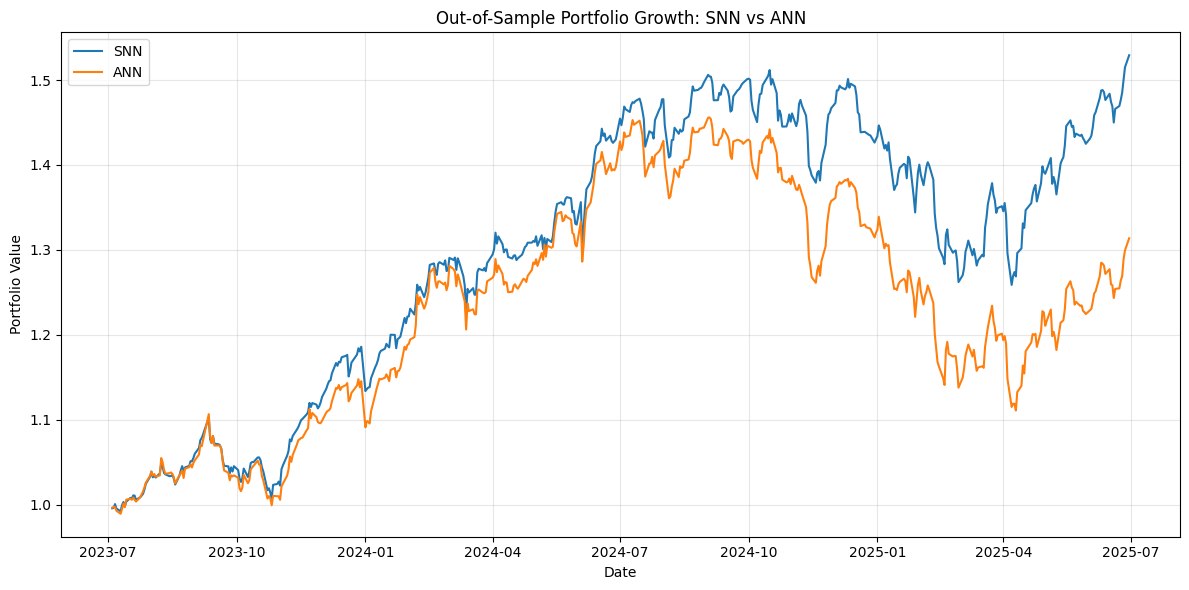

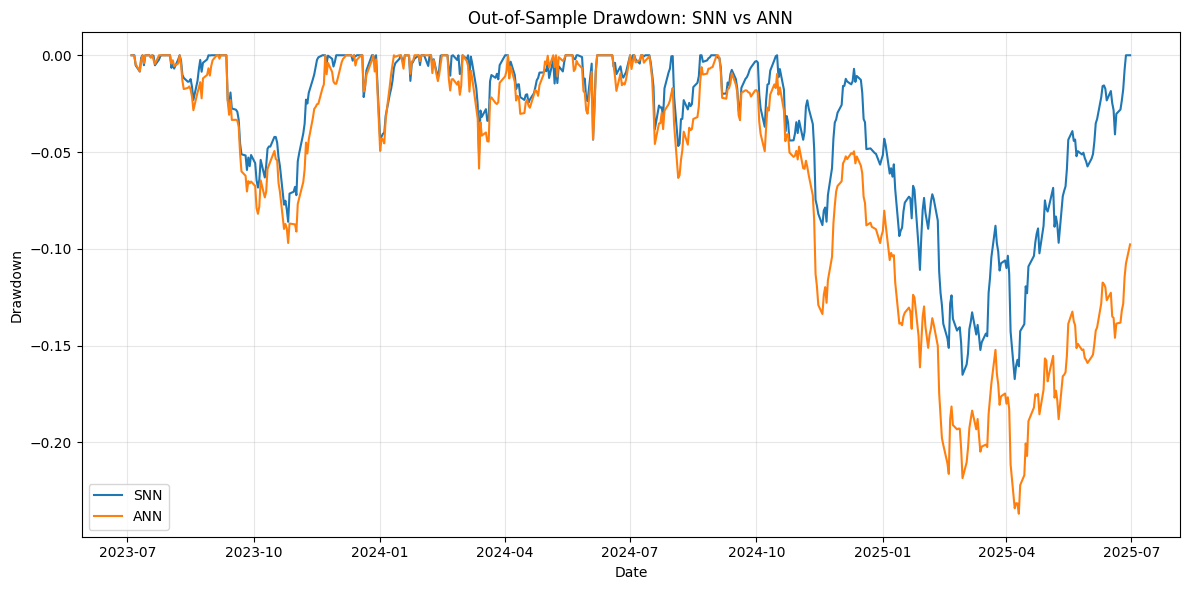

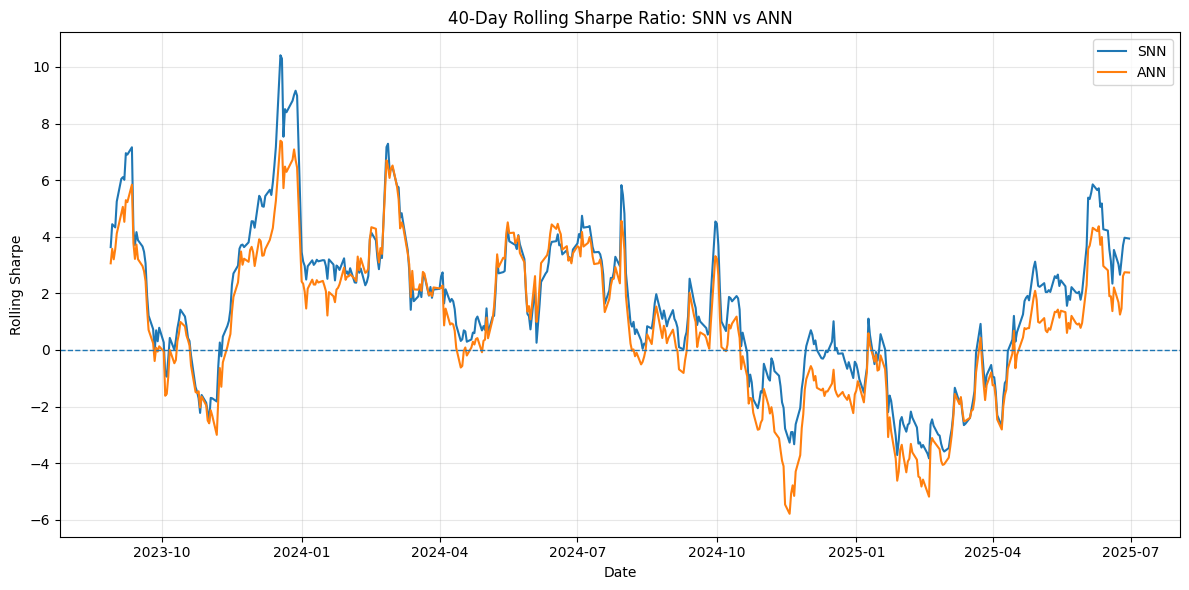

In [20]:
# Cell 17 — SNN vs ANN Test Performance Visualization
# ---------------------------------------------------------

import matplotlib.pyplot as plt


# ---------------------------------------------------------
# 1. Cumulative portfolio growth
# ---------------------------------------------------------

plt.figure(figsize=(12, 6))

plt.plot(
    snn_test["equity"],
    label="SNN"
)

plt.plot(
    ann_test["equity"],
    label="ANN"
)

plt.title(
    "Out-of-Sample Portfolio Growth: SNN vs ANN"
)

plt.xlabel("Date")

plt.ylabel(
    "Portfolio Value"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ---------------------------------------------------------
# 2. Drawdown comparison
# ---------------------------------------------------------

snn_running_max = (
    snn_test["equity"].cummax()
)

ann_running_max = (
    ann_test["equity"].cummax()
)


snn_drawdown = (
    snn_test["equity"]
    / snn_running_max
    - 1
)

ann_drawdown = (
    ann_test["equity"]
    / ann_running_max
    - 1
)


plt.figure(figsize=(12, 6))

plt.plot(
    snn_drawdown,
    label="SNN"
)

plt.plot(
    ann_drawdown,
    label="ANN"
)

plt.title(
    "Out-of-Sample Drawdown: SNN vs ANN"
)

plt.xlabel("Date")

plt.ylabel(
    "Drawdown"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ---------------------------------------------------------
# 3. Rolling Sharpe comparison
# ---------------------------------------------------------

plt.figure(figsize=(12, 6))

plt.plot(
    snn_test["rolling_sharpe"],
    label="SNN"
)

plt.plot(
    ann_test["rolling_sharpe"],
    label="ANN"
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title(
    "40-Day Rolling Sharpe Ratio: SNN vs ANN"
)

plt.xlabel("Date")

plt.ylabel(
    "Rolling Sharpe"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

## Cell 20 — Benchmark comparison

For a meaningful investment result, compare the SNN/ANN portfolios with the same-period market benchmarks.

The benchmark calculation should use the **exact same start/end dates and return convention**. If your portfolio uses adjusted prices, use a compatible total-return benchmark.

Do not compare a price-return portfolio against a total-return index without explicitly stating the difference.

In [21]:
# Cell 18 — Equal-Weight Benchmark
# ---------------------------------------------------------
# Benchmark uses the SAME 50 representative assets.
# No training or optimization is performed.
# ---------------------------------------------------------

# ---------------------------------------------------------
# 1. Equal-weight portfolio
# ---------------------------------------------------------

equal_weights_50 = (
    np.ones(N_ASSETS) / N_ASSETS
)


# ---------------------------------------------------------
# 2. Daily equal-weight returns
# ---------------------------------------------------------

equal_daily_returns = (
    test_simple_returns
    .mul(equal_weights_50, axis=1)
    .sum(axis=1)
)


# ---------------------------------------------------------
# 3. Initial transaction cost
# ---------------------------------------------------------
#
# Equal-weight portfolio is already equal-weight at
# formation, so turnover is zero under the same assumption
# used for the optimized portfolios.

equal_turnover = 0.0

equal_transaction_cost = (
    TRANSACTION_COST *
    equal_turnover
)


# ---------------------------------------------------------
# 4. Calculate benchmark metrics
# ---------------------------------------------------------

equal_test = calculate_test_metrics(
    equal_daily_returns
)


# ---------------------------------------------------------
# 5. Print benchmark
# ---------------------------------------------------------

print("\n" + "=" * 60)
print("EQUAL-WEIGHT BENCHMARK")
print("=" * 60)

print(
    "Cumulative return:",
    f"{equal_test['cumulative_return']:.2%}"
)

print(
    "CAGR:",
    f"{equal_test['CAGR']:.2%}"
)

print(
    "Annualized volatility:",
    f"{equal_test['volatility']:.2%}"
)

print(
    "Sharpe ratio:",
    f"{equal_test['Sharpe']:.4f}"
)

print(
    "Maximum drawdown:",
    f"{equal_test['max_drawdown']:.2%}"
)

print(
    "40-day mean rolling Sharpe:",
    f"{equal_test['rolling_sharpe'].mean():.4f}"
)

print("=" * 60)


# ---------------------------------------------------------
# 6. Final three-way comparison
# ---------------------------------------------------------

comparison = pd.DataFrame({

    "SNN": [

        snn_test["cumulative_return"],
        snn_test["CAGR"],
        snn_test["volatility"],
        snn_test["Sharpe"],
        snn_test["max_drawdown"],
        snn_test["rolling_sharpe"].mean()

    ],

    "ANN": [

        ann_test["cumulative_return"],
        ann_test["CAGR"],
        ann_test["volatility"],
        ann_test["Sharpe"],
        ann_test["max_drawdown"],
        ann_test["rolling_sharpe"].mean()

    ],

    "Equal Weight": [

        equal_test["cumulative_return"],
        equal_test["CAGR"],
        equal_test["volatility"],
        equal_test["Sharpe"],
        equal_test["max_drawdown"],
        equal_test["rolling_sharpe"].mean()

    ]

}, index=[

    "Cumulative Return",
    "CAGR",
    "Annualized Volatility",
    "Sharpe Ratio",
    "Maximum Drawdown",
    "Mean 40D Rolling Sharpe"

])


print("\n" + "=" * 70)
print("FINAL OUT-OF-SAMPLE COMPARISON")
print("=" * 70)

print(
    comparison.to_string(
        formatters={
            "SNN": lambda x: f"{x:.4f}",
            "ANN": lambda x: f"{x:.4f}",
            "Equal Weight": lambda x: f"{x:.4f}"
        }
    )
)

print("=" * 70)


EQUAL-WEIGHT BENCHMARK
Cumulative return: 56.70%
CAGR: 24.48%
Annualized volatility: 12.30%
Sharpe ratio: 1.8424
Maximum drawdown: -14.30%
40-day mean rolling Sharpe: 1.9528

FINAL OUT-OF-SAMPLE COMPARISON
                            SNN     ANN Equal Weight
Cumulative Return        0.5291  0.3136       0.5670
CAGR                     0.2300  0.1422       0.2448
Annualized Volatility    0.1452  0.1553       0.1230
Sharpe Ratio             1.4989  0.9340       1.8424
Maximum Drawdown        -0.1673 -0.2370      -0.1430
Mean 40D Rolling Sharpe  1.5668  0.8724       1.9528


### Cell 19 — Generalization Analysis

In [22]:
# Cell 19 — Train vs Test Generalization Analysis
# ---------------------------------------------------------

# ---------------------------------------------------------
# 1. Training metrics
# ---------------------------------------------------------

snn_train_sharpe = sparse_sharpe.item()
snn_train_return = sparse_return.item()
snn_train_vol = sparse_volatility.item()

ann_train_sharpe = ann_sparse_sharpe.item()
ann_train_return = ann_sparse_return.item()
ann_train_vol = ann_sparse_volatility.item()


# ---------------------------------------------------------
# 2. Test metrics
# ---------------------------------------------------------

snn_test_sharpe = snn_test["Sharpe"]
snn_test_cagr = snn_test["CAGR"]
snn_test_vol = snn_test["volatility"]

ann_test_sharpe = ann_test["Sharpe"]
ann_test_cagr = ann_test["CAGR"]
ann_test_vol = ann_test["volatility"]


# ---------------------------------------------------------
# 3. Generalization gaps
# ---------------------------------------------------------

snn_sharpe_gap = (
    snn_train_sharpe -
    snn_test_sharpe
)

ann_sharpe_gap = (
    ann_train_sharpe -
    ann_test_sharpe
)


snn_return_gap = (
    snn_train_return -
    snn_test_cagr
)

ann_return_gap = (
    ann_train_return -
    ann_test_cagr
)


# ---------------------------------------------------------
# 4. Relative SNN advantage over ANN
# ---------------------------------------------------------

return_advantage = (
    snn_test_cagr -
    ann_test_cagr
)

sharpe_advantage = (
    snn_test_sharpe -
    ann_test_sharpe
)

drawdown_advantage = (
    abs(ann_test["max_drawdown"]) -
    abs(snn_test["max_drawdown"])
)

volatility_advantage = (
    ann_test_vol -
    snn_test_vol
)


# ---------------------------------------------------------
# 5. Print
# ---------------------------------------------------------

print("\n" + "=" * 70)
print("GENERALIZATION ANALYSIS")
print("=" * 70)


print("\nTRAINING → TEST SHARPE")

print(
    f"SNN: {snn_train_sharpe:.4f}"
    f" → {snn_test_sharpe:.4f}"
    f" | Gap: {snn_sharpe_gap:.4f}"
)

print(
    f"ANN: {ann_train_sharpe:.4f}"
    f" → {ann_test_sharpe:.4f}"
    f" | Gap: {ann_sharpe_gap:.4f}"
)


print("\nTRAINING → TEST RETURN")

print(
    f"SNN: {snn_train_return:.2%}"
    f" → {snn_test_cagr:.2%}"
    f" | Gap: {snn_return_gap:.2%}"
)

print(
    f"ANN: {ann_train_return:.2%}"
    f" → {ann_test_cagr:.2%}"
    f" | Gap: {ann_return_gap:.2%}"
)


print("\nSNN ADVANTAGE OVER ANN — TEST")

print(
    "CAGR advantage:",
    f"{return_advantage:.2%}"
)

print(
    "Sharpe advantage:",
    f"{sharpe_advantage:.4f}"
)

print(
    "Volatility advantage:",
    f"{volatility_advantage:.2%}"
)

print(
    "Drawdown advantage:",
    f"{drawdown_advantage:.2%}"
)


# ---------------------------------------------------------
# 6. Comparison table
# ---------------------------------------------------------

generalization = pd.DataFrame({

    "Training Sharpe": [
        snn_train_sharpe,
        ann_train_sharpe
    ],

    "Test Sharpe": [
        snn_test_sharpe,
        ann_test_sharpe
    ],

    "Sharpe Gap": [
        snn_sharpe_gap,
        ann_sharpe_gap
    ],

    "Training Return": [
        snn_train_return,
        ann_train_return
    ],

    "Test CAGR": [
        snn_test_cagr,
        ann_test_cagr
    ],

    "CAGR Gap": [
        snn_return_gap,
        ann_return_gap
    ]

}, index=["SNN", "ANN"])


print("\n" + "=" * 70)
print("MODEL GENERALIZATION TABLE")
print("=" * 70)

print(
    generalization.to_string(
        formatters={
            "Training Sharpe":
                lambda x: f"{x:.4f}",

            "Test Sharpe":
                lambda x: f"{x:.4f}",

            "Sharpe Gap":
                lambda x: f"{x:.4f}",

            "Training Return":
                lambda x: f"{x:.2%}",

            "Test CAGR":
                lambda x: f"{x:.2%}",

            "CAGR Gap":
                lambda x: f"{x:.2%}"
        }
    )
)

print("=" * 70)


GENERALIZATION ANALYSIS

TRAINING → TEST SHARPE
SNN: 2.4022 → 1.4989 | Gap: 0.9033
ANN: 2.7002 → 0.9340 | Gap: 1.7661

TRAINING → TEST RETURN
SNN: 34.25% → 23.00% | Gap: 11.25%
ANN: 38.20% → 14.22% | Gap: 23.98%

SNN ADVANTAGE OVER ANN — TEST
CAGR advantage: 8.78%
Sharpe advantage: 0.5648
Volatility advantage: 1.01%
Drawdown advantage: 6.96%

MODEL GENERALIZATION TABLE
    Training Sharpe Test Sharpe Sharpe Gap Training Return Test CAGR CAGR Gap
SNN          2.4022      1.4989     0.9033          34.25%    23.00%   11.25%
ANN          2.7002      0.9340     1.7661          38.20%    14.22%   23.98%


### Cell 20 — Statistical Significance of SNN vs ANN

In [23]:
# Cell 20 — Statistical Significance Analysis
# ---------------------------------------------------------
# Paired daily comparison of SNN vs ANN
# Test period only.
# ---------------------------------------------------------

from scipy import stats
import numpy as np


# ---------------------------------------------------------
# 1. Align daily returns
# ---------------------------------------------------------

comparison_returns = pd.DataFrame({

    "SNN": snn_daily_returns,

    "ANN": ann_daily_returns

}).dropna()


# Daily difference

return_difference = (
    comparison_returns["SNN"]
    -
    comparison_returns["ANN"]
)


# ---------------------------------------------------------
# 2. Basic statistics
# ---------------------------------------------------------

mean_difference = (
    return_difference.mean()
)

std_difference = (
    return_difference.std()
)

n_observations = (
    len(return_difference)
)


annualized_difference = (
    mean_difference * 252
)


# ---------------------------------------------------------
# 3. Paired t-test
# ---------------------------------------------------------

t_statistic, p_value = (
    stats.ttest_rel(
        comparison_returns["SNN"],
        comparison_returns["ANN"]
    )
)


# ---------------------------------------------------------
# 4. Percentage of days SNN outperformed ANN
# ---------------------------------------------------------

snn_better_days = (
    return_difference > 0
).sum()

ann_better_days = (
    return_difference < 0
).sum()

equal_days = (
    return_difference == 0
).sum()


snn_better_pct = (
    snn_better_days /
    n_observations
)


# ---------------------------------------------------------
# 5. Bootstrap confidence interval
# ---------------------------------------------------------

np.random.seed(42)

N_BOOTSTRAP = 10000

bootstrap_means = np.empty(
    N_BOOTSTRAP
)

for i in range(N_BOOTSTRAP):

    sample = np.random.choice(
        return_difference.values,
        size=n_observations,
        replace=True
    )

    bootstrap_means[i] = (
        sample.mean()
    )


ci_lower = np.percentile(
    bootstrap_means,
    2.5
)

ci_upper = np.percentile(
    bootstrap_means,
    97.5
)


# Annualized CI

annualized_ci_lower = (
    ci_lower * 252
)

annualized_ci_upper = (
    ci_upper * 252
)


# ---------------------------------------------------------
# 6. Print results
# ---------------------------------------------------------

print("\n" + "=" * 70)
print("STATISTICAL SIGNIFICANCE — SNN vs ANN")
print("=" * 70)

print(
    "Test observations:",
    n_observations
)

print(
    "Mean daily return difference:",
    f"{mean_difference:.6f}"
)

print(
    "Annualized return difference:",
    f"{annualized_difference:.2%}"
)

print(
    "Std. dev. of daily difference:",
    f"{std_difference:.6f}"
)

print(
    "Paired t-statistic:",
    f"{t_statistic:.4f}"
)

print(
    "Paired t-test p-value:",
    f"{p_value:.6f}"
)

print(
    "SNN outperformed ANN on:",
    f"{snn_better_days}/{n_observations}",
    f"({snn_better_pct:.2%})",
)

print(
    "ANN outperformed SNN on:",
    f"{ann_better_days}/{n_observations}",
    f"({ann_better_days/n_observations:.2%})",
)

print(
    "\nBootstrap 95% CI for daily return difference:"
)

print(
    f"[{ci_lower:.6f}, {ci_upper:.6f}]"
)

print(
    "\nBootstrap 95% CI for annualized difference:"
)

print(
    f"[{annualized_ci_lower:.2%}, "
    f"{annualized_ci_upper:.2%}]"
)

print("=" * 70)


# ---------------------------------------------------------
# 7. Interpretation
# ---------------------------------------------------------

print("\nINTERPRETATION:")

if p_value < 0.05:

    print(
        "The SNN-ANN daily return difference is "
        "statistically significant at the 5% level."
    )

else:

    print(
        "The SNN-ANN daily return difference is "
        "NOT statistically significant at the 5% level."
    )


STATISTICAL SIGNIFICANCE — SNN vs ANN
Test observations: 517
Mean daily return difference: 0.000288
Annualized return difference: 7.26%
Std. dev. of daily difference: 0.002976
Paired t-statistic: 2.2011
Paired t-test p-value: 0.028172
SNN outperformed ANN on: 296/517 (57.25%)
ANN outperformed SNN on: 221/517 (42.75%)

Bootstrap 95% CI for daily return difference:
[0.000036, 0.000541]

Bootstrap 95% CI for annualized difference:
[0.92%, 13.62%]

INTERPRETATION:
The SNN-ANN daily return difference is statistically significant at the 5% level.


## Cell 21 — HAC / Newey-West Robustness Test

In [24]:
# Cell 21 — HAC Robustness Test
# ---------------------------------------------------------
# Tests whether the SNN-ANN return difference remains
# statistically significant after accounting for
# autocorrelation and heteroskedasticity.
# ---------------------------------------------------------

import statsmodels.api as sm


# ---------------------------------------------------------
# 1. SNN - ANN daily return difference
# ---------------------------------------------------------

diff = (
    snn_daily_returns
    -
    ann_daily_returns
).dropna()


# ---------------------------------------------------------
# 2. Regression of return difference on a constant
# ---------------------------------------------------------

X = np.ones(
    (len(diff), 1)
)

y = diff.values


# ---------------------------------------------------------
# 3. OLS with HAC/Newey-West standard errors
# ---------------------------------------------------------
#
# 40 lags is consistent with the 40-day rolling
# performance horizon used elsewhere in the analysis.

hac_model = sm.OLS(
    y,
    X
).fit(
    cov_type="HAC",
    cov_kwds={
        "maxlags": 40
    }
)


# ---------------------------------------------------------
# 4. Extract statistics
# ---------------------------------------------------------

hac_mean = (
    hac_model.params[0]
)

hac_se = (
    hac_model.bse[0]
)

hac_t = (
    hac_model.tvalues[0]
)

hac_p = (
    hac_model.pvalues[0]
)


# 95% confidence interval

hac_ci = (
    hac_model.conf_int(
        alpha=0.05
    )[0]
)


# Annualized

hac_annual_mean = (
    hac_mean * 252
)

hac_annual_ci_lower = (
    hac_ci[0] * 252
)

hac_annual_ci_upper = (
    hac_ci[1] * 252
)


# ---------------------------------------------------------
# 5. Print
# ---------------------------------------------------------

print("\n" + "=" * 70)
print("HAC / NEWEY-WEST ROBUSTNESS TEST")
print("=" * 70)

print(
    "Observations:",
    len(diff)
)

print(
    "Mean daily SNN - ANN:",
    f"{hac_mean:.6f}"
)

print(
    "Annualized difference:",
    f"{hac_annual_mean:.2%}"
)

print(
    "HAC standard error:",
    f"{hac_se:.6f}"
)

print(
    "HAC t-statistic:",
    f"{hac_t:.4f}"
)

print(
    "HAC p-value:",
    f"{hac_p:.6f}"
)

print(
    "\n95% HAC CI — daily:"
)

print(
    f"[{hac_ci[0]:.6f}, {hac_ci[1]:.6f}]"
)

print(
    "\n95% HAC CI — annualized:"
)

print(
    f"[{hac_annual_ci_lower:.2%}, "
    f"{hac_annual_ci_upper:.2%}]"
)

print("=" * 70)


# ---------------------------------------------------------
# 6. Interpretation
# ---------------------------------------------------------

print("\nINTERPRETATION:")

if hac_p < 0.05:

    print(
        "SNN-ANN outperformance remains statistically "
        "significant at the 5% level after HAC adjustment."
    )

elif hac_p < 0.10:

    print(
        "SNN-ANN outperformance remains significant "
        "at the 10% level, but not at the 5% level "
        "after HAC adjustment."
    )

else:

    print(
        "SNN-ANN outperformance is not statistically "
        "significant after HAC adjustment."
    )


HAC / NEWEY-WEST ROBUSTNESS TEST
Observations: 517
Mean daily SNN - ANN: 0.000288
Annualized difference: 7.26%
HAC standard error: 0.000101
HAC t-statistic: 2.8597
HAC p-value: 0.004241

95% HAC CI — daily:
[0.000091, 0.000486]

95% HAC CI — annualized:
[2.28%, 12.24%]

INTERPRETATION:
SNN-ANN outperformance remains statistically significant at the 5% level after HAC adjustment.


### Cell 22 — Final Research Results Table

In [25]:
# Cell 22 — Final Research Results Table
# ---------------------------------------------------------

final_results = pd.DataFrame({

    "Training Sharpe": [
        sparse_sharpe.item(),
        ann_sparse_sharpe.item(),
        np.nan
    ],

    "Test Cumulative Return": [
        snn_test["cumulative_return"],
        ann_test["cumulative_return"],
        equal_test["cumulative_return"]
    ],

    "Test CAGR": [
        snn_test["CAGR"],
        ann_test["CAGR"],
        equal_test["CAGR"]
    ],

    "Test Volatility": [
        snn_test["volatility"],
        ann_test["volatility"],
        equal_test["volatility"]
    ],

    "Test Sharpe": [
        snn_test["Sharpe"],
        ann_test["Sharpe"],
        equal_test["Sharpe"]
    ],

    "Max Drawdown": [
        snn_test["max_drawdown"],
        ann_test["max_drawdown"],
        equal_test["max_drawdown"]
    ],

    "Mean 40D Rolling Sharpe": [
        snn_test["rolling_sharpe"].mean(),
        ann_test["rolling_sharpe"].mean(),
        equal_test["rolling_sharpe"].mean()
    ],

    "Initial Turnover": [
        snn_turnover,
        ann_turnover,
        equal_turnover
    ],

    "Training Time (sec)": [
        training_time,
        ann_training_time,
        np.nan
    ]

}, index=[
    "SNN",
    "ANN",
    "Equal Weight"
])


print("\n" + "=" * 90)
print("FINAL RESEARCH RESULTS")
print("=" * 90)

print(
    final_results.to_string(
        formatters={
            "Training Sharpe":
                lambda x: "-" if pd.isna(x) else f"{x:.4f}",

            "Test Cumulative Return":
                lambda x: f"{x:.2%}",

            "Test CAGR":
                lambda x: f"{x:.2%}",

            "Test Volatility":
                lambda x: f"{x:.2%}",

            "Test Sharpe":
                lambda x: f"{x:.4f}",

            "Max Drawdown":
                lambda x: f"{x:.2%}",

            "Mean 40D Rolling Sharpe":
                lambda x: f"{x:.4f}",

            "Initial Turnover":
                lambda x: f"{x:.4f}",

            "Training Time (sec)":
                lambda x: "-" if pd.isna(x) else f"{x:.2f}"
        }
    )
)

print("=" * 90)


# ---------------------------------------------------------
# Statistical significance summary
# ---------------------------------------------------------

print("\n" + "=" * 90)
print("SNN vs ANN STATISTICAL ROBUSTNESS")
print("=" * 90)

print(
    "HAC t-statistic:",
    f"{hac_t:.4f}"
)

print(
    "HAC p-value:",
    f"{hac_p:.6f}"
)

print(
    "Annualized return difference:",
    f"{hac_annual_mean:.2%}"
)

print(
    "95% HAC CI:",
    f"[{hac_annual_ci_lower:.2%}, "
    f"{hac_annual_ci_upper:.2%}]"
)

print("=" * 90)


FINAL RESEARCH RESULTS
             Training Sharpe Test Cumulative Return Test CAGR Test Volatility Test Sharpe Max Drawdown Mean 40D Rolling Sharpe Initial Turnover Training Time (sec)
SNN                   2.4022                 52.91%    23.00%          14.52%      1.4989      -16.73%                  1.5668           1.1629                2.63
ANN                   2.7002                 31.36%    14.22%          15.53%      0.9340      -23.70%                  0.8724           1.2384                0.59
Equal Weight             NaN                 56.70%    24.48%          12.30%      1.8424      -14.30%                  1.9528           0.0000                 NaN

SNN vs ANN STATISTICAL ROBUSTNESS
HAC t-statistic: 2.8597
HAC p-value: 0.004241
Annualized return difference: 7.26%
95% HAC CI: [2.28%, 12.24%]


### Save everything

In [26]:
# Cell 23 — Save Experiment Artifacts

import json
from pathlib import Path

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)


# ---------------------------------------------------------
# Save model weights
# ---------------------------------------------------------

torch.save(
    snn_model.state_dict(),
    OUTPUT_DIR / "snn_model.pt"
)

torch.save(
    ann_model.state_dict(),
    OUTPUT_DIR / "ann_model.pt"
)


# ---------------------------------------------------------
# Save portfolio weights
# ---------------------------------------------------------

snn_portfolio.to_csv(
    OUTPUT_DIR / "snn_portfolio.csv",
    index=False
)

ann_portfolio.to_csv(
    OUTPUT_DIR / "ann_portfolio.csv",
    index=False
)


# ---------------------------------------------------------
# Save selected assets
# ---------------------------------------------------------

pd.DataFrame({
    "ticker": selected_assets
}).to_csv(
    OUTPUT_DIR / "selected_assets.csv",
    index=False
)


# ---------------------------------------------------------
# Save final metrics
# ---------------------------------------------------------

final_results.to_csv(
    OUTPUT_DIR / "final_results.csv"
)


# ---------------------------------------------------------
# Save statistical results
# ---------------------------------------------------------

statistical_results = pd.DataFrame({

    "metric": [
        "HAC t-statistic",
        "HAC p-value",
        "Annualized SNN-ANN difference",
        "HAC CI lower",
        "HAC CI upper"
    ],

    "value": [
        hac_t,
        hac_p,
        hac_annual_mean,
        hac_annual_ci_lower,
        hac_annual_ci_upper
    ]

})

statistical_results.to_csv(
    OUTPUT_DIR / "statistical_results.csv",
    index=False
)


# ---------------------------------------------------------
# Save configuration
# ---------------------------------------------------------

config = {

    "seed": SEED,

    "train_start": str(TRAIN_START),
    "train_end": str(TRAIN_END),

    "test_start": str(TEST_START),
    "test_end": str(TEST_END),

    "min_completeness":
        MIN_TRAIN_COMPLETENESS,

    "population_size":
        POP_SIZE,

    "snn_epochs":
        SNN_EPOCHS,

    "snn_learning_rate":
        SNN_LR,

    "ann_hidden":
        ANN_HIDDEN,

    "ann_epochs":
        ANN_EPOCHS,

    "ann_learning_rate":
        ANN_LR,

    "final_k":
        FINAL_K,

    "transaction_cost":
        TRANSACTION_COST

}

with open(
    OUTPUT_DIR / "experiment_config.json",
    "w"
) as f:

    json.dump(
        config,
        f,
        indent=4
    )


print("\n" + "=" * 60)
print("EXPERIMENT ARTIFACTS SAVED")
print("=" * 60)

for file in OUTPUT_DIR.iterdir():

    print(file)

print("=" * 60)


EXPERIMENT ARTIFACTS SAVED
outputs/ann_portfolio.csv
outputs/selected_assets.csv
outputs/statistical_results.csv
outputs/snn_model.pt
outputs/ann_model.pt
outputs/snn_portfolio.csv
outputs/final_results.csv
outputs/experiment_config.json
